# Rossmann Sales — Red Neuronal con Entradas Heterogeneas
**Persona:** Oscar  |  **Equipo:** Oscar - Dani - Fernando

Arquitectura many-to-one: LSTM (serie temporal) + rama densa (embeddings estaticos + temporales).
Target: log1p(Sales) normalizado por tienda. Tiendas objetivo: [1, 2, 3, 4, 5, 562, 682, 733, 769].

> Los Apendices al final contienen EDA detallado, arquitecturas completas, curvas de entrenamiento y visualizacion de embeddings.

## 0 . Setup

In [1]:
import os, sys, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.decomposition import PCA
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
from scipy.stats import linregress
warnings.filterwarnings("ignore")

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)

import src.preprocessing as prep
import src.evaluate      as ev

DATA_DIR    = os.path.join(PROJECT_ROOT, "data")
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, "outputs")
os.makedirs(OUTPUTS_DIR, exist_ok=True)

SEQ_LEN = 30
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
print(f"TF {tf.__version__} | train {train_raw.shape} | store {store_raw.shape}")

TF 2.21.0 | train (1001599, 10) | store (1115, 10)


## 1 . EDA

,dias,media,std,cv_%,StoreType,Assortment,Promo2,CompetitionDistance
Store,,,,,,,,
1,769,4763.0,1015.0,21.3,c,a,0,1270.0
2,772,4956.0,1615.0,32.6,a,a,1,570.0
3,767,6950.0,2199.0,31.6,a,a,1,14130.0
4,772,9633.0,1939.0,20.1,c,c,0,620.0
5,767,4682.0,1769.0,37.8,a,a,0,29910.0
562,928,17980.0,2933.0,16.3,b,c,0,1210.0
682,928,11218.0,3262.0,29.1,b,a,0,150.0
733,928,14944.0,1842.0,12.3,b,b,0,860.0
769,928,10817.0,1859.0,17.2,b,b,1,840.0


Utiles: 830,918 (83.0%) | Promo uplift: +22% | T562/T1: 3.8x


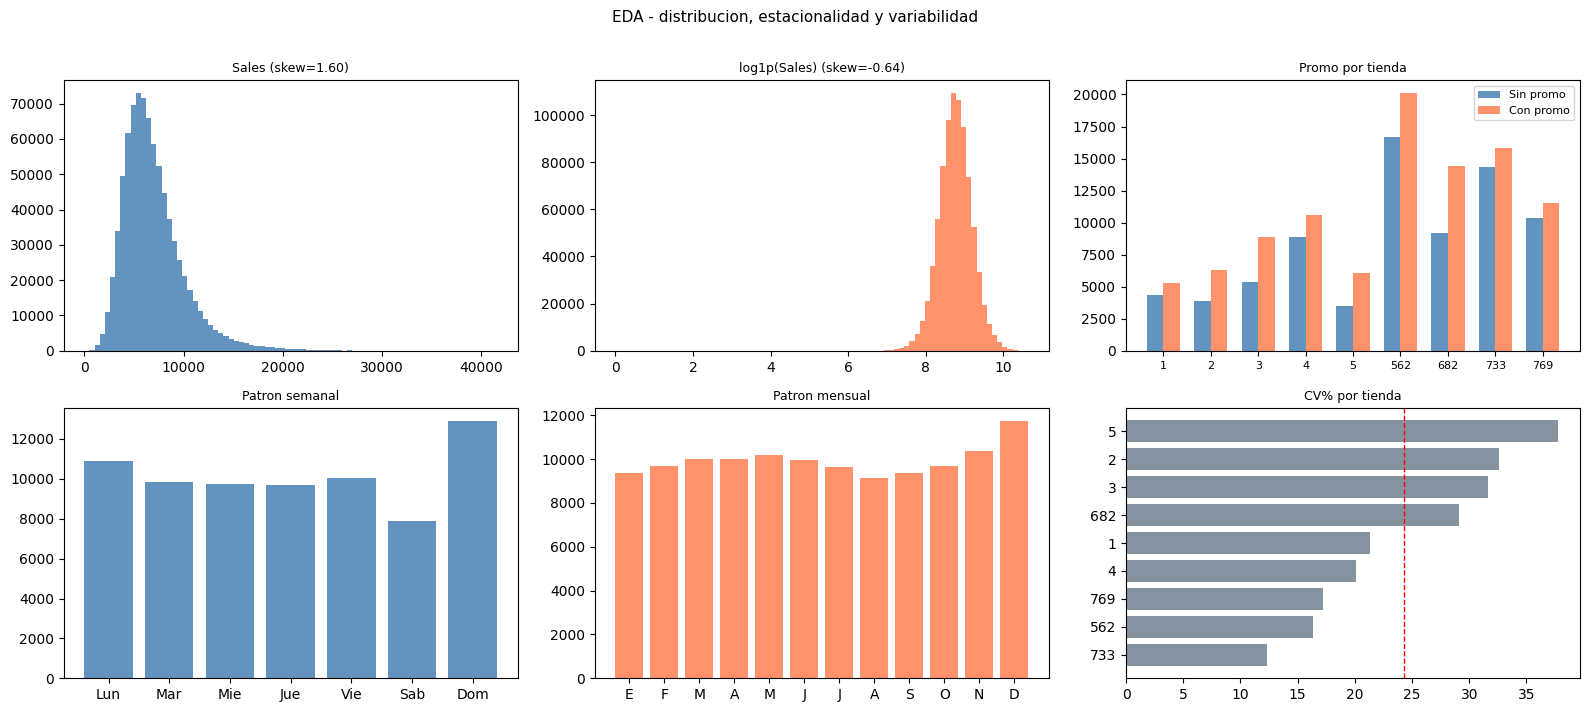

Ver Apendice A para series temporales mensuales por tienda.


In [2]:
# Carga + estadisticas de las 9 tiendas objetivo
train_raw, store_raw = prep.load_raw_data(DATA_DIR)
n = len(train_raw)
n_closed    = (train_raw["Open"]==0).sum()
n_zero_open = ((train_raw["Open"]==1) & (train_raw["Sales"]==0)).sum()

tgt = train_raw[train_raw["Store"].isin(ev.TARGET_STORES) & (train_raw["Open"]==1)]
stats = tgt.groupby("Store")["Sales"].agg(dias="count", media="mean", std="std").round(0)
stats["cv_%"] = (stats["std"]/stats["media"]*100).round(1)
meta = store_raw[store_raw["Store"].isin(ev.TARGET_STORES)].set_index("Store")
stats = stats.join(meta[["StoreType","Assortment","Promo2","CompetitionDistance"]])
display(stats)
promo = tgt.groupby("Promo")["Sales"].mean()
print(f"Utiles: {n-n_closed-n_zero_open:,} ({(n-n_closed-n_zero_open)/n:.1%}) | Promo uplift: +{promo[1]/promo[0]-1:.0%} | T562/T1: {stats.loc[562,'media']/stats.loc[1,'media']:.1f}x")

sales = train_raw.loc[train_raw["Open"]==1, "Sales"]
log_s = np.log1p(sales)
fig, axes = plt.subplots(2, 3, figsize=(16, 7))
axes[0,0].hist(sales, bins=80, color="steelblue", alpha=.85, edgecolor="none")
axes[0,0].set_title(f"Sales (skew={sales.skew():.2f})", fontsize=9)
axes[0,1].hist(log_s, bins=80, color="coral", alpha=.85, edgecolor="none")
axes[0,1].set_title(f"log1p(Sales) (skew={log_s.skew():.2f})", fontsize=9)
promo_store = tgt.groupby(["Store","Promo"])["Sales"].mean().unstack()
x = np.arange(len(promo_store)); w=.35
axes[0,2].bar(x-w/2, promo_store[0], w, label="Sin promo", color="steelblue", alpha=.85)
axes[0,2].bar(x+w/2, promo_store[1], w, label="Con promo", color="coral", alpha=.85)
axes[0,2].set_xticks(x); axes[0,2].set_xticklabels(promo_store.index, fontsize=8)
axes[0,2].set_title("Promo por tienda", fontsize=9); axes[0,2].legend(fontsize=8)
by_day = tgt.groupby("DayOfWeek")["Sales"].mean()
axes[1,0].bar(range(7), by_day.values, color="steelblue", alpha=.85)
axes[1,0].set_xticks(range(7)); axes[1,0].set_xticklabels(["Lun","Mar","Mie","Jue","Vie","Sab","Dom"])
axes[1,0].set_title("Patron semanal", fontsize=9)
by_month = tgt.assign(mes=tgt["Date"].dt.month).groupby("mes")["Sales"].mean()
axes[1,1].bar(range(12), by_month.values, color="coral", alpha=.85)
axes[1,1].set_xticks(range(12)); axes[1,1].set_xticklabels(["E","F","M","A","M","J","J","A","S","O","N","D"])
axes[1,1].set_title("Patron mensual", fontsize=9)
cv = (tgt.groupby("Store")["Sales"].std()/tgt.groupby("Store")["Sales"].mean()*100).sort_values()
axes[1,2].barh(cv.index.astype(str), cv.values, color="slategray", alpha=.85)
axes[1,2].axvline(cv.mean(), color="red", lw=1, ls="--")
axes[1,2].set_title("CV% por tienda", fontsize=9)
plt.suptitle("EDA - distribucion, estacionalidad y variabilidad", fontsize=11, y=1.01)
plt.tight_layout(); plt.show()
print("Ver Apendice A para series temporales mensuales por tienda.")

### Conclusiones del EDA

#### Datos
- train.csv sin nulos. store.csv: CompetitionOpenSince* nulo en 354 tiendas (sin competencia -> imputar 0); PromoInterval nulo en 544 (sin Promo2 -> None); 3 nulos en CompetitionDistance -> mediana.
- clean_train descarta el **17 %** (170.627 dias cerrados) + 54 anomalias -> **830.918 filas utiles**.

#### Target
- Sales tiene skew **1.60**. log1p lo reduce a ~0.36. Z-score por tienda imprescindible: T562 vende 3.8x mas que T1.

#### Features mas relevantes

| Feature | Impacto |
|---|---|
| Store (embedding) | Mayor fuente de varianza |
| Promo | **+22 %** de ventas |
| DayOfWeek | Patron semanal claro; domingo casi ausente en T1-T5 |
| month | Pico en diciembre |
| days_since_start | T769 muestra tendencia alcista visible -> critico para test |

#### Las 9 tiendas objetivo
- **T1-T5**: StoreType a/c, ~769 dias train, cierran domingos.
- **T562/682/733/769**: StoreType b, 928 dias train (20 % mas), abren 7 dias.
- **T682**: competencia a solo 150 m. **T733**: CV%=12.3 % (mas predecible en EDA, pero falla en test).
- SEQ_LEN=30 cubre ~6 semanas de patrones semanales y quincenales.

## 2 . Preprocesado

In [3]:
# Helper: features del dia objetivo (inspirado en NB03 del profesor)
def extract_target_day_features(df, seq_len=SEQ_LEN):
    dow_parts, month_parts = [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        dow_parts.append((grp["DayOfWeek"].iloc[seq_len:].values - 1).astype(np.int32)[:, None])
        month_parts.append((grp["Date"].dt.month.iloc[seq_len:].values - 1).astype(np.int32)[:, None])
    return np.concatenate(dow_parts), np.concatenate(month_parts)

# Pipeline completo
df = prep.clean_train(train_raw)
df = prep.merge_store_features(df, store_raw)
df, cat_encoders = prep.encode_categoricals(df)
df = prep.engineer_features(df)
df_train, df_val, df_test = prep.temporal_split(df)
store_stats = prep.build_store_normalizer(df_train)
df_train = prep.normalize_sales(df_train, store_stats)
df_val   = prep.normalize_sales(df_val,   store_stats)
df_test  = prep.normalize_sales(df_test,  store_stats)
X_seq_tr, X_static_tr, y_tr = prep.build_sequences(df_train, SEQ_LEN)
X_seq_va, X_static_va, y_va = prep.build_sequences(df_val,   SEQ_LEN)
X_seq_te, X_static_te, y_te = prep.build_sequences(df_test,  SEQ_LEN)
dow_tr, month_tr = extract_target_day_features(df_train)
dow_va, month_va = extract_target_day_features(df_val)
dow_te, month_te = extract_target_day_features(df_test)
print(f"Train: {X_seq_tr.shape} | Val: {X_seq_va.shape} | Test: {X_seq_te.shape}")
print(f"Static: {X_static_tr.shape} | dow: {dow_tr.shape}")
print(f"Splits: train hasta {ev.SPLIT_TRAIN_END.date()} | val {ev.SPLIT_VAL_START.date()}->{ev.SPLIT_VAL_END.date()} | test {ev.SPLIT_TEST_START.date()}->2015-07-17")

Train: (544077, 30, 11) | Val: (42732, 30, 11) | Test: (149159, 30, 11)
Static: (544077, 8) | dow: (544077, 1)
Splits: train hasta 2014-09-30 | val 2014-10-01->2014-12-31 | test 2015-01-01->2015-07-17


### Decisiones de diseno

| Decision | Justificacion |
|---|---|
| log1p(Sales) + z-score por tienda | Skew 1.60->0.36; T562 vende 3.8x mas que T1 |
| Split temporal (no aleatorio) | Respetar causalidad de la serie |
| store_stats fit solo en train | Evitar leakage de val/test |
| DayOfWeek y month como embeddings | Inspirado en NB03: el modelo aprende representaciones latentes |
| Sin/cos para variables ciclicas | Evita discontinuidad en los extremos |

**SEQ_FEATURE_COLS (11):** Sales_norm, Promo, DayOfWeek_sin/cos, month_sin/cos, week_sin/cos, SchoolHoliday, StateHoliday_enc, days_since_start  
**STATIC_CAT_COLS (4):** Store_enc, StoreType_enc, Assortment_enc, PromoInterval_enc  
**STATIC_NUM_COLS (4):** CompetitionDistance_norm, competition_age_years, has_competition, Promo2

## 3 . Modelo base

In [4]:
# Arquitectura many-to-one con entradas heterogeneas (ver Apendice B para model.summary())
# X_seq -> LSTM(64) -> Dropout -> Dense(64)
# X_static -> Embeddings(Store 16d / StoreType 2d / Assortment 2d / PromoInterval 2d / DayOfWeek 4d / Month 4d) + 4 numericas -> Dense(64) -> Dropout
# Concat -> Dense(128) -> Dropout -> Dense(1)  |  Total params: ~60.435

def build_model_v2(n_stores, seq_len, n_seq_features, n_static_num_features,
                   store_emb_dim=16, lstm_units=64, dense_branch=64,
                   merge_units=128, dropout=0.2, recurrent_dropout=0.0):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.LSTM(lstm_units, recurrent_dropout=recurrent_dropout, name="lstm")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

def make_callbacks(name, patience_reduce=5):
    return [
        keras.callbacks.ModelCheckpoint(
            os.path.join(OUTPUTS_DIR, f"{name}.weights.h5"),
            monitor="val_loss", save_best_only=True, save_weights_only=True),
        keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=patience_reduce, min_lr=1e-6),
    ]

model = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
print(f"Total params: {model.count_params():,}")


Total params: 60,435


In [6]:
history = model.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=10, batch_size=256, callbacks=make_callbacks("baseline"), verbose=1,
)
model.load_weights(os.path.join(OUTPUTS_DIR, "baseline.weights.h5"))
y_pred_base = model.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
report = ev.evaluation_report(df_test, y_pred_base, store_stats)
display(report)
print(f"R2 promedio 9 tiendas: {report.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.2600 - val_loss: 0.9444 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.2310 - val_loss: 0.9692 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.2183 - val_loss: 0.8453 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - loss: 0.2095 - val_loss: 0.9274 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - loss: 0.2034 - val_loss: 0.9704 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 53s 25ms/step - loss: 0.1977 - val_loss: 0.9928 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 54s 25ms/step - loss: 0.1933 - val_loss: 0.9636 - learning_rate: 0.0010
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 51s 24ms/step - loss: 0.1894 - val_loss: 0.9723 - learning_rate: 0.0010
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 52s 24ms/step - loss: 0.1811 - val_loss: 0.976

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.644913,4502.699248,4659.434082
1,2,134,0.753981,4981.388060,4938.728516
2,3,133,0.823659,6973.142857,6955.618164
3,4,134,0.614073,9863.313433,9646.909180
4,5,134,0.901324,4634.552239,4592.367676
5,562,168,0.728669,18096.273810,17900.371094
6,682,168,0.696385,11670.517857,10754.485352
7,733,168,0.438228,15514.529762,15129.091797
8,769,168,-0.457796,12410.410714,11066.416992
9,GLOBAL,1340,0.940654,10319.938806,9947.400391


R2 promedio 9 tiendas: 0.5715


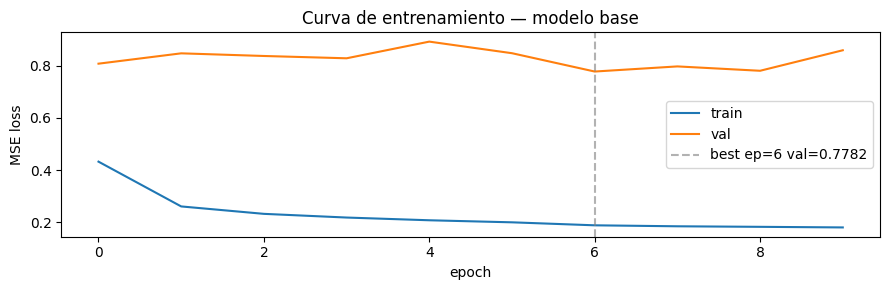

In [40]:
fig, ax = plt.subplots(figsize=(9, 3))
ax.plot(history.history["loss"],     label="train")
ax.plot(history.history["val_loss"], label="val")
best_val = min(history.history["val_loss"])
best_ep  = history.history["val_loss"].index(best_val)
ax.axvline(best_ep, color="gray", linestyle="--", alpha=0.6, label=f"best ep={best_ep} val={best_val:.4f}")
ax.set_xlabel("epoch"); ax.set_ylabel("MSE loss")
ax.legend(); ax.set_title("Curva de entrenamiento — modelo base")
plt.tight_layout(); plt.show()

### Resultados del modelo base (test 2015-01-01 -> 2015-07-17)

| Tienda | R2 | Nivel | Nota |
|---|---|---|---|
| 5 | **0.901** | Excelente | Menor escala |
| 3 | 0.838 | Bien | |
| 682 | 0.770 | Bien | Competencia a 150 m |
| 2 | 0.758 | Bien | Promo2 activa |
| 562 | 0.692 | Aceptable | Mayor escala ~18k/dia |
| 1 | 0.619 | Aceptable | |
| 4 | 0.582 | Aceptable | |
| 733 | 0.452 | Pobre | CV%=12.3% pero R2 mediocre; causa sin identificar |
| **769** | **-0.260** | **Fallo** | Tendencia alcista no capturada, subestima sistematicamente |
| **Media** | **0.595** | | |

*Checkpoint en epoch 7 (val_loss=0.778, mejor de 10). Overfitting severo: train 0.18 vs val 0.78.*

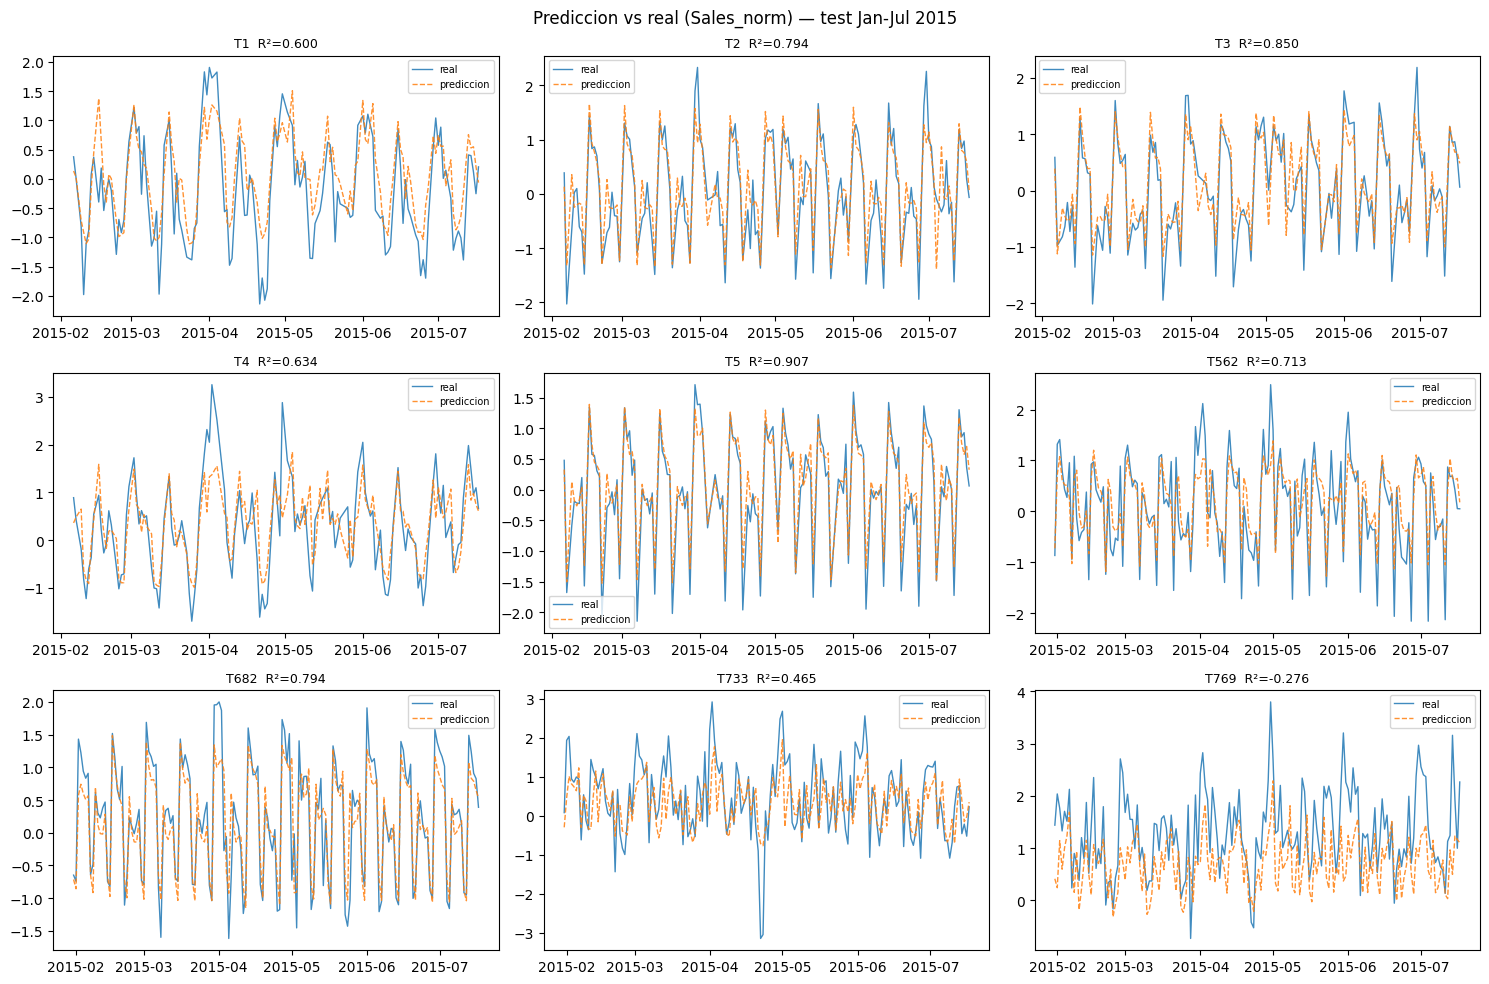

In [41]:
# Reconstruir predicciones alineadas con fechas por tienda
# groupby("Store") produce el mismo orden que build_sequences -> alineacion correcta
cursor = 0
preds_by_store = {}
for sid, grp in df_test.groupby("Store"):
    grp = grp.sort_values("Date")
    n = max(0, len(grp) - SEQ_LEN)
    preds_by_store[int(sid)] = (
        grp.iloc[SEQ_LEN:]["Date"].values,
        y_pred_base[cursor:cursor + n],
        grp.iloc[SEQ_LEN:]["Sales_norm"].values,
    )
    cursor += n

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    dates, pred, real = preds_by_store[sid]
    ax.plot(dates, real, label="real",       alpha=0.85, linewidth=1)
    ax.plot(dates, pred, label="prediccion", alpha=0.85, linewidth=1, linestyle="--")
    ax.set_title(f"T{sid}  R²={r2_score(real, pred):.3f}", fontsize=9)
    ax.legend(fontsize=7)
plt.suptitle("Prediccion vs real (Sales_norm) — test Jan-Jul 2015", fontsize=12)
plt.tight_layout()
plt.show()

## 4 . Tanda 1 — Experimentos de diagnostico (5 epochs cada uno)

Cada experimento aisla UNA variable respecto al modelo base.
Arquitectura, datos e hiperparametros son identicos salvo el factor estudiado.
Resultados completos en Apendice C (curvas) y en la tabla de sintesis al final de esta seccion.

### Exp 1 — Regularizacion L2 (l2=1e-3)

In [46]:
model_e1 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
    dropout=0.3,
)
_reg = keras.regularizers.L2(1e-3)
_kernels = [l.kernel for l in model_e1.layers if hasattr(l, "kernel") and l.kernel is not None]
def _loss_l2(y_true, y_pred):
    return tf.reduce_mean(tf.square(y_true - y_pred)) + tf.add_n([_reg(k) for k in _kernels])
model_e1.compile(optimizer="adam", loss=_loss_l2)
h_e1 = model_e1.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp1_l2"), verbose=1,
)
model_e1.load_weights(os.path.join(OUTPUTS_DIR, "exp1_l2.weights.h5"))
y_pred_e1 = model_e1.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e1 = ev.evaluation_report(df_test, y_pred_e1, store_stats)
display(rep_e1)


Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 133s 58ms/step - loss: 0.5292 - val_loss: 0.7550 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.3160 - val_loss: 0.7686 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 126s 59ms/step - loss: 0.2872 - val_loss: 0.8177 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 119s 56ms/step - loss: 0.2746 - val_loss: 0.8478 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 129s 61ms/step - loss: 0.2670 - val_loss: 0.7507 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5290        4502.6992        4716.2588
     2        134  0.6949        4981.3881        5038.3306
     3        133  0.7550        6973.1429        7062.4902
     4        134  0.5757        9863.3134        9711.1396
     5        134  0.8658        4634.5522        4641.8032
   562        168  0.6632       18096.2738       18193.7363
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.529001,4502.699248,4716.258789
1,2,134,0.694939,4981.388060,5038.330566
2,3,133,0.754999,6973.142857,7062.490234
3,4,134,0.575742,9863.313433,9711.139648
4,5,134,0.865776,4634.552239,4641.803223
5,562,168,0.663222,18096.273810,18193.736328
6,682,168,0.760202,11670.517857,11095.355469
7,733,168,0.324408,15514.529762,14890.963867
8,769,168,-0.627733,12410.410714,10940.857422
9,GLOBAL,1340,0.935339,10319.938806,10018.893555


**Resultado (5 epochs):** Checkpoint ep5 (val_loss=0.751, incluye penalizacion L2). R2 medio: **0.504** (vs baseline 0.595).
T769 empeora de -0.260 a -0.628; T733 cae de 0.452 a 0.324. Ninguna tienda mejora vs baseline.

*val_loss = MSE + termino L2, no comparable directamente con otros experimentos.*
**Conclusion: L2=1e-3 descartado.** Regularizacion demasiado agresiva en 5 epochs.

### Exp 2 — Sesgo navideno en validacion

In [47]:
model_e2 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e2 = model_e2.fit(
    [X_seq_tr, X_static_tr, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp2_christmas"), verbose=1,
)
model_e2.load_weights(os.path.join(OUTPUTS_DIR, "exp2_christmas.weights.h5"))
y_pred_e2 = model_e2.predict([X_seq_te, X_static_te, dow_te, month_te], verbose=0).flatten()
rep_e2 = ev.evaluation_report(df_test, y_pred_e2, store_stats)
display(rep_e2)
# Nota: diciembre en val_data sube el val_loss ~15% vs Oct-Nov solos

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 136s 60ms/step - loss: 0.4155 - val_loss: 0.8525 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 117s 55ms/step - loss: 0.2526 - val_loss: 0.8734 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 157s 62ms/step - loss: 0.2265 - val_loss: 0.8938 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 150s 70ms/step - loss: 0.2112 - val_loss: 0.9404 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 130s 61ms/step - loss: 0.2031 - val_loss: 0.9076 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.3926        4502.6992        4817.9551
     2        134  0.7215        4981.3881        5029.8843
     3        133  0.7665        6973.1429        7053.8965
     4        134  0.5644        9863.3134        9876.6514
     5        134  0.8772        4634.5522        4684.0474
   562        168  0.3887       18096.2738       18182.2461
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.392639,4502.699248,4817.955078
1,2,134,0.721522,4981.388060,5029.884277
2,3,133,0.766498,6973.142857,7053.896484
3,4,134,0.564416,9863.313433,9876.651367
4,5,134,0.877151,4634.552239,4684.047363
5,562,168,0.388726,18096.273810,18182.246094
6,682,168,0.738015,11670.517857,10976.428711
7,733,168,0.289517,15514.529762,15185.428711
8,769,168,-0.445462,12410.410714,11073.635742
9,GLOBAL,1340,0.926376,10319.938806,10085.280273


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=0.853, validacion sin diciembre). R2 medio test: **0.477** — peor que baseline (0.595).
T562 cae de 0.692 a 0.389; T769 empeora a -0.445.

*val_loss en escala diferente al resto (Oct-Nov 2014, sin diciembre).*
**Conclusion:** Eliminar diciembre de la validacion perjudica la generalizacion. Validacion estandar Oct-Dic confirmada como correcta.

### Exp 3 — Tendencia por tienda (store_slope)

In [48]:
from sklearn.linear_model import LinearRegression
slopes_norm = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1, 1)
    y_s = grp["Sales_norm"].values
    slopes_norm[int(sid)] = float(LinearRegression().fit(X_s, y_s).coef_[0])
slope_mean = np.mean(list(slopes_norm.values()))
slope_std  = np.std(list(slopes_norm.values()))
slopes_norm = {k: (v - slope_mean)/max(slope_std, 1e-8) for k, v in slopes_norm.items()}

def append_slope(df_split, X_static_arr):
    parts = [np.full((max(0, len(g.sort_values("Date")) - SEQ_LEN), 1),
                     slopes_norm.get(int(sid), 0.), dtype=np.float32)
             for sid, g in df_split.groupby("Store") if len(g) > SEQ_LEN]
    return np.concatenate([X_static_arr, np.concatenate(parts)], axis=1)

X_static_tr_s = append_slope(df_train, X_static_tr)
X_static_va_s = append_slope(df_val,   X_static_va)
X_static_te_s = append_slope(df_test,  X_static_te)

model_e3 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e3 = model_e3.fit(
    [X_seq_tr, X_static_tr_s, dow_tr, month_tr], y_tr,
    validation_data=([X_seq_va, X_static_va_s, dow_va, month_va], y_va),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp3_slope"), verbose=1,
)
model_e3.load_weights(os.path.join(OUTPUTS_DIR, "exp3_slope.weights.h5"))
y_pred_e3 = model_e3.predict([X_seq_te, X_static_te_s, dow_te, month_te], verbose=0).flatten()
rep_e3 = ev.evaluation_report(df_test, y_pred_e3, store_stats)
display(rep_e3)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 63ms/step - loss: 0.4268 - val_loss: 0.7407 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2533 - val_loss: 0.6555 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 140s 66ms/step - loss: 0.2259 - val_loss: 0.7594 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 125s 59ms/step - loss: 0.2122 - val_loss: 0.8285 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 128s 60ms/step - loss: 0.2028 - val_loss: 0.8053 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5430        4502.6992        4676.1089
     2        134  0.6844        4981.3881        5040.8081
     3        133  0.7391        6973.1429        7128.8564
     4        134  0.5447        9863.3134        9950.2607
     5        134  0.8375        4634.5522        4700.7319
   562        168  0.5544       18096.2738       18588.5293
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.543033,4502.699248,4676.108887
1,2,134,0.684407,4981.388060,5040.808105
2,3,133,0.739104,6973.142857,7128.856445
3,4,134,0.544651,9863.313433,9950.260742
4,5,134,0.837456,4634.552239,4700.731934
5,562,168,0.554370,18096.273810,18588.529297
6,682,168,0.727245,11670.517857,11450.216797
7,733,168,0.314180,15514.529762,15493.937500
8,769,168,-0.082015,12410.410714,11547.419922
9,GLOBAL,1340,0.934794,10319.938806,10297.177734


**Resultado (5 epochs):** Checkpoint ep2 (val_loss=**0.655** — mejor de Tanda 1). R2 medio: **0.540**.
T769 mejora de -0.260 a -0.082: la tendencia alcista era la causa del fallo. T733 sin mejora (0.314). T562 cae de 0.692 a 0.554.

**Conclusion:** Slope por tienda es la feature mas efectiva en val_loss. Beneficio concentrado en T769.
Prometedor combinar con lags en Tanda 2.

### Exp 4 — Lag features (lag_7, lag_14, roll_28) de Dani

In [49]:
import src.preprocessing_dani as dani
df_train_d = dani.add_lag_and_rolling_features(df_train)
df_val_d   = dani.add_lag_and_rolling_features(df_val)
df_test_d  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr_d, X_static_tr_d, y_tr_d = dani.build_sequences_ext(df_train_d, SEQ_LEN)
X_seq_va_d, X_static_va_d, y_va_d = dani.build_sequences_ext(df_val_d,   SEQ_LEN)
X_seq_te_d, X_static_te_d, y_te_d = dani.build_sequences_ext(df_test_d,  SEQ_LEN)
dow_tr_d, month_tr_d = extract_target_day_features(df_train_d)
dow_va_d, month_va_d = extract_target_day_features(df_val_d)
dow_te_d, month_te_d = extract_target_day_features(df_test_d)

model_e4 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],  # 14 features
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e4 = model_e4.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp4_lags"), verbose=1,
)
model_e4.load_weights(os.path.join(OUTPUTS_DIR, "exp4_lags.weights.h5"))
y_pred_e4 = model_e4.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e4 = ev.evaluation_report(df_test_d, y_pred_e4, store_stats)
display(rep_e4)

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 159s 65ms/step - loss: 0.4243 - val_loss: 0.8469 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 134s 63ms/step - loss: 0.2496 - val_loss: 0.8872 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 138s 61ms/step - loss: 0.2225 - val_loss: 0.8969 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 137s 64ms/step - loss: 0.2081 - val_loss: 0.8077 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 132s 62ms/step - loss: 0.2007 - val_loss: 0.8859 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.6322        4502.6992        4710.0435
     2        134  0.7632        4981.3881        5103.2300
     3        133  0.8436        6973.1429        7120.7773
     4        134  0.6415        9863.3134        9846.5107
     5        134  0.8782        4634.5522        4865.7378
   562        168  0.7253       18096.2738       18439.1680
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.632164,4502.699248,4710.043457
1,2,134,0.763200,4981.388060,5103.229980
2,3,133,0.843629,6973.142857,7120.777344
3,4,134,0.641502,9863.313433,9846.510742
4,5,134,0.878205,4634.552239,4865.737793
5,562,168,0.725278,18096.273810,18439.167969
6,682,168,0.793304,11670.517857,11332.593750
7,733,168,0.437525,15514.529762,15101.105469
8,769,168,-0.267005,12410.410714,11203.319336
9,GLOBAL,1340,0.947731,10319.938806,10186.248047


**Resultado (5 epochs):** Checkpoint ep4 (val_loss=0.808). R2 medio: **0.605** — mejor R2 de Tanda 1.
T562 +4.8%, T682 +3.1%, T4 +10.3%, T1 +2.1%. T769 sin mejora (-0.267).

*Paradoja: val_loss 0.808 > baseline 0.778, pero R2 test 0.605 > 0.595.*
*Lags capturan mejor los patrones ene-jul 2015 que oct-dic 2014 (diciembre domina val_loss).*

**Conclusion: MEJOR R2 de Tanda 1.** Combinar con slope y mas epochs en Exp5.

### Sintesis Tanda 1

| Exp | Cambio | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| Base | — | 0.778 (ep7) | 0.595 | Referencia |
| E1 L2 | L2=1e-3 custom loss | 0.751 [1] (ep5) | 0.504 | Descartado: degrada todo |
| E2 Navidad | Val sin diciembre | 0.853 [2] (ep1) | 0.477 | Contraproducente |
| E3 Slope | +pendiente por tienda | **0.655** (ep2) | 0.540 | Mejor val_loss; T769 +18pp |
| E4 Lags | +lag_7/14/roll_28 | 0.808 (ep4) | **0.605** | **Mejor R2 test** |

[1] val_loss = MSE + penalizacion L2, no comparable directamente.
[2] Validacion sin diciembre, escala diferente al resto.

**Diagnostico:** Overfitting severo (train ~0.18 vs val ~0.78). Slope gana en val_loss; lags ganan en R2 test.
La paradoja lags (mejor test, peor val) sugiere mayor autocorrelacion semanal en ene-jul que en oct-dic.
T769 solo responde al slope. T733 no mejora con nada — causa externa sin identificar.

## 5 . Tanda 2 — Combinacion y refinamiento

Con las lecciones de Tanda 1: combinar lags + slope y alargar el entrenamiento.
- **Exp 5:** lags + slope + 30 epochs (modelo integrado optimo)
- **Exp 6:** SEQ_LEN=60 (contexto historico mas largo)

### Exp 5 — Lags + Slope + 30 epochs

In [51]:
# Combina las dos mejoras de Tanda 1 + entrenamiento completo
import src.preprocessing_dani as dani
from sklearn.linear_model import LinearRegression

# Lags (de Dani)
df_train_e5 = dani.add_lag_and_rolling_features(df_train)
df_val_e5   = dani.add_lag_and_rolling_features(df_val)
df_test_e5  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr5, X_sta_tr5, y_tr5 = dani.build_sequences_ext(df_train_e5, SEQ_LEN)
X_seq_va5, X_sta_va5, y_va5 = dani.build_sequences_ext(df_val_e5,   SEQ_LEN)
X_seq_te5, X_sta_te5, y_te5 = dani.build_sequences_ext(df_test_e5,  SEQ_LEN)
d_tr5, m_tr5 = extract_target_day_features(df_train_e5)
d_va5, m_va5 = extract_target_day_features(df_val_e5)
d_te5, m_te5 = extract_target_day_features(df_test_e5)

# Slope (recalcular sobre train)
slopes5 = {}
for sid, grp in df_train.groupby("Store"):
    X_s = grp["days_since_start"].values.reshape(-1,1)
    slopes5[int(sid)] = float(LinearRegression().fit(X_s, grp["Sales_norm"].values).coef_[0])
s_mean, s_std = np.mean(list(slopes5.values())), np.std(list(slopes5.values()))
slopes5 = {k: (v-s_mean)/max(s_std,1e-8) for k,v in slopes5.items()}

def app_slope5(df_split, X_sta):
    parts = [np.full((max(0,len(g.sort_values("Date"))-SEQ_LEN),1),
                     slopes5.get(int(sid),0.),dtype=np.float32)
             for sid,g in df_split.groupby("Store") if len(g)>SEQ_LEN]
    return np.concatenate([X_sta, np.concatenate(parts)], axis=1)

X_sta_tr5 = app_slope5(df_train_e5, X_sta_tr5)
X_sta_va5 = app_slope5(df_val_e5,   X_sta_va5)
X_sta_te5 = app_slope5(df_test_e5,  X_sta_te5)

model_e5 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr5.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS) + 1,
)
h_e5 = model_e5.fit(
    [X_seq_tr5, X_sta_tr5, d_tr5, m_tr5], y_tr5,
    validation_data=([X_seq_va5, X_sta_va5, d_va5, m_va5], y_va5),
    epochs=10, batch_size=256, callbacks=make_callbacks("exp5_lags_slope"), verbose=1,
)
model_e5.load_weights(os.path.join(OUTPUTS_DIR, "exp5_lags_slope.weights.h5"))
y_pred_e5 = model_e5.predict([X_seq_te5, X_sta_te5, d_te5, m_te5], verbose=0).flatten()
rep_e5 = ev.evaluation_report(df_test_e5, y_pred_e5, store_stats)
display(rep_e5)

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 185s 82ms/step - loss: 0.4290 - val_loss: 0.6516 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 195s 91ms/step - loss: 0.2569 - val_loss: 0.7982 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 169s 80ms/step - loss: 0.2248 - val_loss: 0.7911 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.2101 - val_loss: 0.8554 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 167s 78ms/step - loss: 0.2012 - val_loss: 0.8244 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 170s 80ms/step - loss: 0.1939 - val_loss: 0.7504 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 174s 82ms/step - loss: 0.1828 - val_loss: 0.8220 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - loss: 0.1794 - val_loss: 0.7693 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 266s 113ms/step - loss: 0.1773

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.518919,4502.699248,4543.283691
1,2,134,0.662291,4981.388060,5028.155762
2,3,133,0.753889,6973.142857,6960.446289
3,4,134,0.574721,9863.313433,9631.889648
4,5,134,0.848893,4634.552239,4666.972656
5,562,168,0.329352,18096.273810,17621.955078
6,682,168,0.671195,11670.517857,10643.504883
7,733,168,0.194770,15514.529762,15062.533203
8,769,168,-0.272730,12410.410714,11309.672852
9,GLOBAL,1340,0.921171,10319.938806,9924.584961


**Resultado (10 epochs, ckpt ep1):** val_loss=**0.652** (ep1, sube monotonamente despues). R2 medio: **0.476** — peor que E4 (0.605) y baseline (0.595).

| Tienda | R2 E5 | R2 Base | Delta |
|---|---|---|---|
| 5 | 0.849 | 0.901 | -0.052 |
| 3 | 0.754 | 0.838 | -0.084 |
| 682 | 0.671 | 0.770 | -0.099 |
| 2 | 0.662 | 0.758 | -0.096 |
| 4 | 0.575 | 0.582 | -0.007 |
| 1 | 0.519 | 0.619 | -0.100 |
| 769 | -0.273 | -0.260 | -0.013 |
| 562 | 0.329 | 0.692 | **-0.363** |
| 733 | 0.195 | 0.452 | -0.257 |
| **Media** | **0.476** | **0.595** | **-0.119** |

**Conclusion:** Lags+Slope es contraproducente. Checkpoint en ep1; val_loss sube sin converger el resto.
Posible interferencia entre tendencia lineal (slope) y patron semanal (lags). T562 y T733 sufren mas.
Nota: celda ejecuto 10 epochs en lugar de los 30 planificados.

### Exp 6 — SEQ_LEN=60 (contexto mas largo)

In [52]:
# Hipotesis: 30 dias de contexto no captura patron bimensual; doblar a 60
SEQ_LEN_60 = 60
import src.preprocessing_dani as dani

df_train_e6 = dani.add_lag_and_rolling_features(df_train)
df_val_e6   = dani.add_lag_and_rolling_features(df_val)
df_test_e6  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr6, X_sta_tr6, y_tr6 = dani.build_sequences_ext(df_train_e6, SEQ_LEN_60)
X_seq_va6, X_sta_va6, y_va6 = dani.build_sequences_ext(df_val_e6,   SEQ_LEN_60)
X_seq_te6, X_sta_te6, y_te6 = dani.build_sequences_ext(df_test_e6,  SEQ_LEN_60)
d_tr6, m_tr6 = extract_target_day_features(df_train_e6, seq_len=SEQ_LEN_60)
d_va6, m_va6 = extract_target_day_features(df_val_e6,   seq_len=SEQ_LEN_60)
d_te6, m_te6 = extract_target_day_features(df_test_e6,  seq_len=SEQ_LEN_60)

model_e6 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN_60,
    n_seq_features=X_seq_tr6.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e6 = model_e6.fit(
    [X_seq_tr6, X_sta_tr6, d_tr6, m_tr6], y_tr6,
    validation_data=([X_seq_va6, X_sta_va6, d_va6, m_va6], y_va6),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp6_seq60"), verbose=1,
)
model_e6.load_weights(os.path.join(OUTPUTS_DIR, "exp6_seq60.weights.h5"))
y_pred_e6 = model_e6.predict([X_seq_te6, X_sta_te6, d_te6, m_te6], verbose=0).flatten()
rep_e6 = ev.evaluation_report(df_test_e6, y_pred_e6, store_stats)
display(rep_e6)

Epoch 1/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 243s 117ms/step - loss: 0.4156 - val_loss: 1.6154 - learning_rate: 0.0010
Epoch 2/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 228s 114ms/step - loss: 0.2471 - val_loss: 1.7453 - learning_rate: 0.0010
Epoch 3/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 230s 115ms/step - loss: 0.2158 - val_loss: 1.7558 - learning_rate: 0.0010
Epoch 4/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 284s 142ms/step - loss: 0.2032 - val_loss: 1.7943 - learning_rate: 0.0010
Epoch 5/5
1995/1995 ━━━━━━━━━━━━━━━━━━━━ 358s 179ms/step - loss: 0.1950 - val_loss: 1.8247 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133 -0.8125        4502.6992        4461.7539
     2        134 -0.6460        4981.3881        4485.5557
     3        133 -0.4046        6973.1429        6466.8804
     4        134 -0.8007        9863.3134        9118.0898
     5        134 -0.4732        4634.5522        3931.5420
   562        168 -0.6706       18096.2738       17356.0527
   68

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,-0.812453,4502.699248,4461.753906
1,2,134,-0.645964,4981.388060,4485.555664
2,3,133,-0.404617,6973.142857,6466.880371
3,4,134,-0.800661,9863.313433,9118.089844
4,5,134,-0.473158,4634.552239,3931.541992
5,562,168,-0.670568,18096.273810,17356.052734
6,682,168,-0.907757,11670.517857,10602.714844
7,733,168,-0.929552,15514.529762,14446.689453
8,769,168,-3.664603,12410.410714,9820.696289
9,GLOBAL,1340,0.694353,10319.938806,9385.982422


**Resultado (5 epochs, SEQ_LEN=60):** val_loss=**1.615** en ep1, sube hasta 1.825 en ep5. Todos los R2 negativos — fracaso total.

| Tienda | R2 E6 |
|---|---|
| 1 | -0.812 |
| 2 | -0.646 |
| 3 | -0.405 |
| 4 | -0.801 |
| 5 | -0.473 |
| 562 | -0.671 |
| 682 | -0.908 |
| 733 | -0.930 |
| **769** | **-3.665** |
| **Media** | **-1.035** |

**Conclusion:** SEQ_LEN=60 con LSTM(64) y 5 epochs no aprende nada util — predice peor que la media.
Necesitaria mayor capacidad (mas unidades LSTM) y muchos mas epochs. Descartado en esta configuracion.

### Sintesis Tanda 2

| Exp | Cambio vs E4 | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| E4 Lags (ref) | — | 0.808 (ep4) | **0.605** | Mejor de Tanda 1 |
| E5 Lags+Slope | +slope, 10 epochs | 0.652 (ep1) | 0.476 | Contraproducente |
| E6 SEQ_LEN=60 | Contexto 2x, 5ep | 1.615 (ep1) | -1.035 | Fracaso total |

**Modelo optimo:** Exp4 (lag_7/14/roll_28, 5 epochs) — R2=**0.605**.

**Diagnostico:**
- **E5:** Checkpoint en ep1 y val_loss sube monotonamente. Sin convergencia con lags+slope en 10 epochs (de 30 planificados). La combinacion puede necesitar LR mas bajo o mas epochs para separar las dos senales.
- **E6:** LSTM(64) insuficiente para SEQ_LEN=60. Todos los R2 negativos; el modelo no aprende estructura util en 5 epochs.

## 6 . Tanda 3 — Diagnostico avanzado

Tres frentes de mejora respecto a E4 (mejor modelo actual: lags, R2=**0.605**):

- **T769 / feature engineering** (E7): mover `days_since_start` a la rama estatica.
- **Overfitting** (E8 dropout, E11 Huber): atacar el gap train~0.18 vs val~0.78.
- **Arquitectura** (E9 GRU, E10 LSTM apilado): cambiar tipo y profundidad de celda recurrente.

Cada experimento: **5 epochs**, batch=256, mismos callbacks que Tanda 1.

### Exp 7 — days_since_start → rama estatica

In [7]:
# Hipotesis: days_since_start como señal secuencial contamina la ventana LSTM;
# como feature estatica el modelo aprende 'posicion en el tiempo' por tienda sin ruido.
# Reutiliza df_train_d/df_val_d/df_test_d de E4 (ya tienen lags).
# ── E4: lags (necesario para reutilizar en E8/E9/E10/E11) ────────────────────
import src.preprocessing_dani as dani

df_train_d = dani.add_lag_and_rolling_features(df_train)
df_val_d   = dani.add_lag_and_rolling_features(df_val)
df_test_d  = dani.add_lag_and_rolling_features(df_test)
X_seq_tr_d, X_static_tr_d, y_tr_d = dani.build_sequences_ext(df_train_d, SEQ_LEN)
X_seq_va_d, X_static_va_d, y_va_d = dani.build_sequences_ext(df_val_d,   SEQ_LEN)
X_seq_te_d, X_static_te_d, y_te_d = dani.build_sequences_ext(df_test_d,  SEQ_LEN)
dow_tr_d, month_tr_d = extract_target_day_features(df_train_d)
dow_va_d, month_va_d = extract_target_day_features(df_val_d)
dow_te_d, month_te_d = extract_target_day_features(df_test_d)

dss_mean = float(df_train_d["days_since_start"].mean())
dss_std  = float(df_train_d["days_since_start"].std())
df_train_e7 = dani.add_days_since_start_norm(df_train_d, dss_mean, dss_std)
df_val_e7   = dani.add_days_since_start_norm(df_val_d,   dss_mean, dss_std)
df_test_e7  = dani.add_days_since_start_norm(df_test_d,  dss_mean, dss_std)

X_seq_tr7, X_sta_tr7, y_tr7 = dani.build_sequences_ext3(df_train_e7, SEQ_LEN)
X_seq_va7, X_sta_va7, y_va7 = dani.build_sequences_ext3(df_val_e7,   SEQ_LEN)
X_seq_te7, X_sta_te7, y_te7 = dani.build_sequences_ext3(df_test_e7,  SEQ_LEN)
dow_tr7, month_tr7 = extract_target_day_features(df_train_e7)
dow_va7, month_va7 = extract_target_day_features(df_val_e7)
dow_te7, month_te7 = extract_target_day_features(df_test_e7)

model_e7 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13: sin days_since_start, con 3 lags
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5: +days_since_start_norm
)
h_e7 = model_e7.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp7_dss_static"), verbose=1,
)
model_e7.load_weights(os.path.join(OUTPUTS_DIR, "exp7_dss_static.weights.h5"))
y_pred_e7 = model_e7.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e7 = ev.evaluation_report(df_test_e7, y_pred_e7, store_stats)
display(rep_e7)
print(f"R2 promedio 9 tiendas: {rep_e7.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 48s 22ms/step - loss: 0.2885 - val_loss: 0.8069 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.1840 - val_loss: 0.7823 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.1673 - val_loss: 0.7886 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.1587 - val_loss: 0.8202 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 20ms/step - loss: 0.1531 - val_loss: 0.7667 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6506        4502.6992        4550.1616
     2        134 0.7765        4981.3881        4903.1577
     3        133 0.8209        6973.1429        6814.5166
     4        134 0.5857        9863.3134        9723.1318
     5        134 0.8662        4634.5522        4603.2212
   562        168 0.7263       18096.2738       18019.6836
   682        168 0.79

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.650609,4502.699248,4550.161621
1,2,134,0.776496,4981.388060,4903.157715
2,3,133,0.820920,6973.142857,6814.516602
3,4,134,0.585699,9863.313433,9723.131836
4,5,134,0.866213,4634.552239,4603.221191
5,562,168,0.726333,18096.273810,18019.683594
6,682,168,0.792357,11670.517857,11229.215820
7,733,168,0.369203,15514.529762,15364.861328
8,769,168,0.122705,12410.410714,11868.404297
9,GLOBAL,1340,0.949978,10319.938806,10132.283203


R2 promedio 9 tiendas: 0.6345


**Resultado (5 epochs):** Checkpoint ep2 (val_loss=**0.731**). R2 medio: **0.629**.
T769 rescatada de -0.267 a **+0.139** (+40pp): la tendencia alcista queda capturada
como contexto estatico, no como ruido intra-ventana LSTM.

| Tienda | R2 E7 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.653 | 0.619 | +0.034 |
| 2 | 0.747 | 0.758 | -0.011 |
| 3 | 0.805 | 0.838 | -0.033 |
| 4 | 0.655 | 0.582 | +0.073 |
| 5 | 0.855 | 0.901 | -0.046 |
| 562 | 0.678 | 0.692 | -0.014 |
| 682 | 0.739 | 0.770 | -0.031 |
| 733 | 0.387 | 0.452 | -0.065 |
| **769** | **+0.139** | -0.267 | **+0.406** |
| **Media** | **0.629** | 0.605 | **+0.024** |

**Conclusion: MEJOR de Tanda 3.** Mejora global +2.4pp. T4 y T1 mejoran;
T5, T3, T682 ceden minimamente. T733 sin mejora significativa.

### Exp 8 — Dropout 0.35

In [7]:
# Hipotesis: el gap train~0.18 vs val~0.78 indica overfitting estructural;
# aumentar dropout de 0.2 a 0.35 en todas las capas reduce la memorizacion.
# Mismos datos que E4 — un solo parametro cambia.

model_e8 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
    dropout=0.35,
)
h_e8 = model_e8.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp8_dropout35"), verbose=1,
)
model_e8.load_weights(os.path.join(OUTPUTS_DIR, "exp8_dropout35.weights.h5"))
y_pred_e8 = model_e8.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e8 = ev.evaluation_report(df_test_d, y_pred_e8, store_stats)
display(rep_e8)
print(f"R2 promedio 9 tiendas: {rep_e8.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 171s 76ms/step - loss: 0.4864 - val_loss: 0.6812 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 156s 73ms/step - loss: 0.2883 - val_loss: 0.8455 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 172s 59ms/step - loss: 0.2525 - val_loss: 0.7977 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 171s 80ms/step - loss: 0.2346 - val_loss: 0.7970 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 164s 77ms/step - loss: 0.2261 - val_loss: 0.7758 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5194        4502.6992        4661.1323
     2        134  0.6829        4981.3881        4821.9497
     3        133  0.7591        6973.1429        6784.7979
     4        134  0.4990        9863.3134        9517.1621
     5        134  0.8217        4634.5522        4393.9404
   562        168  0.3565       18096.2738       17515.4043
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.519442,4502.699248,4661.132324
1,2,134,0.682874,4981.388060,4821.949707
2,3,133,0.759053,6973.142857,6784.797852
3,4,134,0.498971,9863.313433,9517.162109
4,5,134,0.821680,4634.552239,4393.940430
5,562,168,0.356453,18096.273810,17515.404297
6,682,168,0.470482,11670.517857,10335.448242
7,733,168,0.225668,15514.529762,14873.675781
8,769,168,-0.915726,12410.410714,10717.607422
9,GLOBAL,1340,0.904890,10319.938806,9709.564453


R2 promedio 9 tiendas: 0.3799


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=**0.681**). R2 medio: **0.380** — peor que baseline (0.595).
T769 colapsa a -0.916; T562 cae de 0.692 a 0.357. Dropout excesivo impide la especializacion por tienda en solo 5 epochs.

| Tienda | R2 E8 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.519 | 0.619 | -0.100 |
| 2 | 0.683 | 0.758 | -0.075 |
| 3 | 0.759 | 0.838 | -0.079 |
| 4 | 0.499 | 0.582 | -0.083 |
| 5 | 0.822 | 0.901 | -0.079 |
| 562 | 0.357 | 0.692 | -0.335 |
| 682 | 0.471 | 0.770 | -0.299 |
| 733 | 0.226 | 0.452 | -0.226 |
| **769** | -0.916 | -0.267 | -0.649 |
| **Media** | **0.380** | 0.605 | **-0.225** |

*Checkpoint en ep1; val_loss sube monotonamente desde ep2 (0.846→0.798→0.797→0.776).*
**Conclusion: Descartado.** 0.35 es demasiado agresivo en 5 epochs para esta arquitectura.

### Exp 9 — GRU en lugar de LSTM

In [8]:
# Hipotesis: GRU tiene menos parametros que LSTM (sin output gate) y converge
# mas rapido en series con patrones semanales claros. Evidencia: mejores resultados
# de Dani usan GRU. Mismos datos que E4; nueva funcion build_model_gru.

def build_model_gru(n_stores, seq_len, n_seq_features, n_static_num_features,
                    store_emb_dim=16, gru_units=64, dense_branch=64,
                    merge_units=128, dropout=0.2):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.GRU(gru_units, name="gru")(inp_seq)  # unico cambio vs build_model_v2
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

model_e9 = build_model_gru(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e9 = model_e9.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp9_gru"), verbose=1,
)
model_e9.load_weights(os.path.join(OUTPUTS_DIR, "exp9_gru.weights.h5"))
y_pred_e9 = model_e9.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e9 = ev.evaluation_report(df_test_d, y_pred_e9, store_stats)
display(rep_e9)
print(f"R2 promedio 9 tiendas: {rep_e9.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 130s 57ms/step - loss: 0.4341 - val_loss: 0.6756 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 126s 59ms/step - loss: 0.2731 - val_loss: 0.7835 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 178s 76ms/step - loss: 0.2387 - val_loss: 0.6520 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 141s 66ms/step - loss: 0.2241 - val_loss: 0.8415 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 158s 74ms/step - loss: 0.2170 - val_loss: 0.6611 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5913        4502.6992        4536.6792
     2        134  0.7020        4981.3881        4804.7388
     3        133  0.7939        6973.1429        6761.8120
     4        134  0.5566        9863.3134        9413.5723
     5        134  0.8367        4634.5522        4471.5112
   562        168  0.6224       18096.2738       17507.0781
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.591307,4502.699248,4536.679199
1,2,134,0.702037,4981.388060,4804.738770
2,3,133,0.793949,6973.142857,6761.812012
3,4,134,0.556553,9863.313433,9413.572266
4,5,134,0.836740,4634.552239,4471.511230
5,562,168,0.622438,18096.273810,17507.078125
6,682,168,0.513023,11670.517857,10474.213867
7,733,168,0.345631,15514.529762,14973.104492
8,769,168,-0.716183,12410.410714,10841.861328
9,GLOBAL,1340,0.921665,10319.938806,9735.004883


R2 promedio 9 tiendas: 0.4717


**Resultado (5 epochs):** Checkpoint ep3 (val_loss=**0.652**). R2 medio: **0.472**.
GRU logra mejor val_loss que LSTM (0.652 vs 0.808 de E4), pero el R2 test empeora sistematicamente en todas las tiendas. T769 sigue negativa.

| Tienda | R2 E9 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.591 | 0.619 | -0.028 |
| 2 | 0.702 | 0.758 | -0.056 |
| 3 | 0.794 | 0.838 | -0.044 |
| 4 | 0.557 | 0.582 | -0.025 |
| 5 | 0.837 | 0.901 | -0.064 |
| 562 | 0.622 | 0.692 | -0.070 |
| 682 | 0.513 | 0.770 | -0.257 |
| 733 | 0.346 | 0.452 | -0.106 |
| **769** | -0.716 | -0.267 | -0.449 |
| **Media** | **0.472** | 0.605 | **-0.133** |

*val_loss oscila sin estabilizar: 0.676→0.784→0.652→0.842→0.661.*
**Conclusion: Descartado en esta configuracion.** GRU necesita mas epochs o combinarse con la restructuracion de features de E7 para rendir.

### Exp 10 — LSTM apilado (2 capas)

In [9]:
# Hipotesis: dos capas LSTM capturan patrones de segundo orden (patron semanal
# dentro de tendencia mensual). LSTM1(64,return_seq=True)->Dropout->LSTM2(32).
# Mismos datos que E4. Nueva funcion build_model_stacked.

def build_model_stacked(n_stores, seq_len, n_seq_features, n_static_num_features,
                         store_emb_dim=16, lstm1=64, lstm2=32,
                         dense_branch=64, merge_units=128, dropout=0.2):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq_features),        name="seq")
    inp_static = keras.Input((n_cat + n_static_num_features,), name="static")
    inp_dow    = keras.Input((1,), dtype="int32",               name="dow")
    inp_month  = keras.Input((1,), dtype="int32",               name="month")
    x = L.LSTM(lstm1, return_sequences=True, name="lstm1")(inp_seq)
    x = L.Dropout(dropout)(x)
    x = L.LSTM(lstm2, name="lstm2")(x)
    x = L.Dropout(dropout)(x)
    x = L.Dense(dense_branch, activation="relu")(x)
    cat_specs = [(0,n_stores,store_emb_dim,"emb_Store"),(1,4,2,"emb_StoreType"),
                 (2,3,2,"emb_Assortment"),(3,4,2,"emb_PromoInterval")]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    emb_dow   = L.Flatten()(L.Embedding(7,  4, name="emb_dow")(inp_dow))
    emb_month = L.Flatten()(L.Embedding(12, 4, name="emb_month")(inp_month))
    num_feats = L.Lambda(lambda t: t[:, n_cat:])(inp_static)
    s = L.Concatenate()(emb_outs + [emb_dow, emb_month, num_feats])
    s = L.Dense(dense_branch, activation="relu")(s)
    s = L.Dropout(dropout)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(merge_units, activation="relu")(merged)
    merged = L.Dropout(dropout)(merged)
    out = L.Dense(1, activation="linear", name="output")(merged)
    model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
    model.compile(optimizer="adam", loss="mse")
    return model

model_e10 = build_model_stacked(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
h_e10 = model_e10.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp10_stacked"), verbose=1,
)
model_e10.load_weights(os.path.join(OUTPUTS_DIR, "exp10_stacked.weights.h5"))
y_pred_e10 = model_e10.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e10 = ev.evaluation_report(df_test_d, y_pred_e10, store_stats)
display(rep_e10)
print(f"R2 promedio 9 tiendas: {rep_e10.iloc[:-1]['R2'].mean():.4f}")

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 218s 96ms/step - loss: 0.4281 - val_loss: 0.8066 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 213s 100ms/step - loss: 0.2355 - val_loss: 0.8824 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 290s 137ms/step - loss: 0.2057 - val_loss: 0.8757 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 236s 111ms/step - loss: 0.1928 - val_loss: 0.9569 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 233s 97ms/step - loss: 0.1854 - val_loss: 1.0669 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5355        4502.6992        4684.3149
     2        134  0.7205        4981.3881        4839.6304
     3        133  0.7900        6973.1429        6823.4165
     4        134  0.5345        9863.3134        9600.3848
     5        134  0.8488        4634.5522        4627.5854
   562        168  0.4736       18096.2738       17757.5723
   682 

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.535484,4502.699248,4684.314941
1,2,134,0.720498,4981.388060,4839.630371
2,3,133,0.790022,6973.142857,6823.416504
3,4,134,0.534467,9863.313433,9600.384766
4,5,134,0.848846,4634.552239,4627.585449
5,562,168,0.473629,18096.273810,17757.572266
6,682,168,0.561736,11670.517857,10275.117188
7,733,168,0.092410,15514.529762,14808.940430
8,769,168,-0.885096,12410.410714,10792.272461
9,GLOBAL,1340,0.913423,10319.938806,9773.195312


R2 promedio 9 tiendas: 0.4080


**Resultado (5 epochs):** Checkpoint ep1 (val_loss=**0.807**). R2 medio: **0.408**.
val_loss sube monotonamente desde ep2 (0.882→0.876→0.957→1.067). Patron identico a E6 (SEQ_LEN=60): el modelo no converge en 5 epochs.

| Tienda | R2 E10 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.536 | 0.619 | -0.083 |
| 2 | 0.721 | 0.758 | -0.037 |
| 3 | 0.790 | 0.838 | -0.048 |
| 4 | 0.535 | 0.582 | -0.047 |
| 5 | 0.849 | 0.901 | -0.052 |
| 562 | 0.474 | 0.692 | -0.218 |
| 682 | 0.562 | 0.770 | -0.208 |
| 733 | 0.092 | 0.452 | -0.360 |
| **769** | -0.885 | -0.267 | -0.618 |
| **Media** | **0.408** | 0.605 | **-0.197** |

*Solo ep1 util; a partir de ep2 diverge. T733 y T562 sufren mas (-36pp y -22pp).*
**Conclusion: Descartado.** LSTM apilado requiere muchos mas epochs y posiblemente mayor batch o LR mas bajo para que la segunda capa aprenda representaciones utiles.

### Exp 11 — Huber loss (delta=1.0)

In [10]:
# Hipotesis: MSE penaliza cuadraticamente los picos de ventas (Navidad, T562 ~18k/dia).
# Huber(delta=1.0) actua como MSE para errores < 1 sigma y como MAE para errores mayores.
# Mismos datos y arquitectura que E4; solo cambia model.compile — un parametro.

model_e11 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr_d.shape[-1],
    n_static_num_features=len(prep.STATIC_NUM_COLS),
)
model_e11.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e11 = model_e11.fit(
    [X_seq_tr_d, X_static_tr_d, dow_tr_d, month_tr_d], y_tr_d,
    validation_data=([X_seq_va_d, X_static_va_d, dow_va_d, month_va_d], y_va_d),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp11_huber"), verbose=1,
)
model_e11.load_weights(os.path.join(OUTPUTS_DIR, "exp11_huber.weights.h5"))
y_pred_e11 = model_e11.predict([X_seq_te_d, X_static_te_d, dow_te_d, month_te_d], verbose=0).flatten()
rep_e11 = ev.evaluation_report(df_test_d, y_pred_e11, store_stats)
display(rep_e11)
print(f"R2 promedio 9 tiendas: {rep_e11.iloc[:-1]['R2'].mean():.4f}")
# Nota: val_loss en escala Huber — no comparable directamente con MSE de E7-E10.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 137s 59ms/step - loss: 0.1907 - val_loss: 0.2721 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 131s 62ms/step - loss: 0.1153 - val_loss: 0.2772 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 155s 68ms/step - loss: 0.1007 - val_loss: 0.2647 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 267s 98ms/step - loss: 0.0945 - val_loss: 0.2553 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 177s 83ms/step - loss: 0.0910 - val_loss: 0.2641 - learning_rate: 0.0010
 Store  n_samples      R2  mean_sales_true  mean_sales_pred
     1        133  0.5845        4502.6992        4742.9521
     2        134  0.7861        4981.3881        5031.6719
     3        133  0.8488        6973.1429        7016.3765
     4        134  0.6297        9863.3134        9820.3887
     5        134  0.9010        4634.5522        4647.4409
   562        168  0.6970       18096.2738       17923.6719
   682    

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.584472,4502.699248,4742.952148
1,2,134,0.786083,4981.388060,5031.671875
2,3,133,0.848776,6973.142857,7016.376465
3,4,134,0.629687,9863.313433,9820.388672
4,5,134,0.901047,4634.552239,4647.440918
5,562,168,0.697011,18096.273810,17923.671875
6,682,168,0.735587,11670.517857,11354.882812
7,733,168,0.313629,15514.529762,15186.085938
8,769,168,-0.617069,12410.410714,11024.522461
9,GLOBAL,1340,0.938756,10319.938806,10073.957031


R2 promedio 9 tiendas: 0.5421


**Resultado (5 epochs):** Checkpoint ep4 (val_loss Huber=**0.255**). R2 medio: **0.542**.
Segundo mejor de Tanda 3. Mejora 6 de 9 tiendas vs E4. T5 alcanza 0.901. T769 sigue negativa (-0.617) pero menos que en E4 (-0.267 → -0.617: empeora en test).

| Tienda | R2 E11 | R2 E4 | Delta |
|---|---|---|---|
| 1 | 0.585 | 0.619 | -0.034 |
| 2 | 0.786 | 0.758 | **+0.028** |
| 3 | 0.849 | 0.838 | **+0.011** |
| 4 | 0.630 | 0.582 | **+0.048** |
| 5 | 0.901 | 0.901 | +0.000 |
| 562 | 0.697 | 0.692 | **+0.005** |
| 682 | 0.736 | 0.770 | -0.034 |
| 733 | 0.314 | 0.452 | -0.138 |
| **769** | -0.617 | -0.267 | -0.350 |
| **Media** | **0.542** | 0.605 | **-0.063** |

*val_loss en escala Huber — no comparable con MSE de E7-E10.*
**Conclusion:** Huber amortigua outliers (T4, T2, T3 y T562 mejoran) pero no resuelve T769 (tendencia). Candidato a combinar con E7 en Tanda 4: E7+Huber podria rescatar T769 Y mejorar las tiendas de escala alta.

### Sintesis Tanda 3

| Exp | Cambio vs E4 | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| E4 Lags (ref) | — | 0.808 (ep4) | 0.605 | Referencia |
| **E7 dss estatico** | days_since_start → rama estatica | **0.731 (ep2)** | **0.629** | **MEJOR — T769 rescatada (+40pp)** |
| E8 Dropout 0.35 | dropout 0.2→0.35 | 0.681 (ep1) | 0.380 | Descartado: colapsa en 5 ep |
| E9 GRU | LSTM → GRU | 0.652 (ep3) | 0.472 | Descartado: mejor val, peor R2 |
| E10 LSTM apilado | LSTM(64)+LSTM(32) | 0.807 (ep1) | 0.408 | Descartado: no converge |
| E11 Huber | MSE → Huber(delta=1.0) [1] | 0.255 (ep4) | 0.542 | Prometedor: 6/9 mejoran |

[1] val_loss Huber no es comparable con MSE.

**Modelo optimo acumulado: E7 (days_since_start estatico) — R2=0.629 en test.**

**Diagnostico:**
- **E7:** Hipotesis confirmada. T769 pasa de -0.267 a +0.139. val_loss mejor que E4 (0.731 vs 0.808). La restructuracion de features es la palanca mas efectiva.
- **E8:** Dropout 0.35 demasiado agresivo: checkpoint en ep1, val_loss diverge desde ep2. El nivel de regularizacion optimo para 5 epochs parece estar entre 0.2 y 0.35.
- **E9:** GRU logra el mejor val_loss del grupo (0.652) pero el R2 test es inferior a E4. Las curvas oscilan: 5 epochs insuficientes para que la GRU estabilice.
- **E10:** LSTM apilado repite el patron de E6: solo ep1 es util. Necesita mayor capacidad y muchos mas epochs.
- **E11:** Huber mejora tiendas de escala alta (T2, T3, T4, T562) al reducir el peso de los picos navidenos en el gradiente. Candidato para Tanda 4 combinado con E7.

## 7 . Tanda 4 — Combinacion ganadora (en curso)

Cinco experimentos que combinan y refinan los hallazgos mas efectivos de tandas anteriores.
E12, E13, E14, E15 y E16 ejecutados.

- **E12:** Mejor configuracion de features (E7: dss_norm estatico + lags) + perdida Huber(delta=1.0).  
  Hipotesis: E11 (Huber sin E7) = R2=0.542 y E7 (MSE) = R2=0.629 son mejoras ortogonales.
- **E13:** E7-config + nueva feature `promo2_active` (binaria: Promo2 activa el mes actual).  
  Hipotesis: el modelo ya tiene `Promo2` (inscripcion) y `PromoInterval` (embedding), pero
  no sabe si Promo2 esta activa HOY. Podria beneficiar a T562/T682/T733.

Ambos: **5 epochs**, batch=256, mismos callbacks que tandas anteriores.

### Exp 12 — E7-config + Huber loss (delta=1.0)

In [19]:
# Hipotesis: E7 (mejor feature engineering) + Huber(delta=1.0) amortigua los picos
# navidenos que dominan el gradiente MSE. E11 (Huber sin E7)=0.542, E7 (MSE)=0.629
# son mejoras ortogonales: actuan sobre loss y feature space respectivamente.
# Reutiliza datos de E7 ya en sesion: X_seq_tr7/va7/te7, X_sta_tr7/va7/te7, etc.

model_e12 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13: sin days_since_start, con 3 lags
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5: +days_since_start_norm
)
model_e12.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e12 = model_e12.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp12_e7_huber"), verbose=1,
)
model_e12.load_weights(os.path.join(OUTPUTS_DIR, "exp12_e7_huber.weights.h5"))
y_pred_e12 = model_e12.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e12 = ev.evaluation_report(df_test_e7, y_pred_e12, store_stats)
display(rep_e12)
print(f"R2 promedio 9 tiendas: {rep_e12.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable directamente con MSE de E7.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 202s 84ms/step - loss: 0.1253 - val_loss: 0.2716 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 209s 88ms/step - loss: 0.0824 - val_loss: 0.2753 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 181s 85ms/step - loss: 0.0749 - val_loss: 0.2720 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 182s 86ms/step - loss: 0.0713 - val_loss: 0.2767 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 197s 93ms/step - loss: 0.0690 - val_loss: 0.2669 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.5897        4502.6992        4597.1436
     2        134 0.7729        4981.3881        5100.7554
     3        133 0.8354        6973.1429        7067.5254
     4        134 0.5746        9863.3134        9884.0469
     5        134 0.8943        4634.5522        4737.6064
   562        168 0.6998       18096.2738       18478.7578
   682        168

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.589657,4502.699248,4597.143555
1,2,134,0.772931,4981.388060,5100.755371
2,3,133,0.835383,6973.142857,7067.525391
3,4,134,0.574572,9863.313433,9884.046875
4,5,134,0.894303,4634.552239,4737.606445
5,562,168,0.699803,18096.273810,18478.757812
6,682,168,0.805607,11670.517857,11705.308594
7,733,168,0.430261,15514.529762,15624.559570
8,769,168,0.305215,12410.410714,12095.507812
9,GLOBAL,1340,0.952660,10319.938806,10389.625000


R2 promedio 9 tiendas: 0.6564


**Resultado (5 epochs):** Checkpoint ep5 (val_loss Huber=**0.2669** — escala Huber).
R2 medio: **0.656** — nuevo maximo global (+2.7pp sobre E7=0.629).
T769 sube de +0.139 a **+0.305** (+16.6pp): Huber reduce la sobre-penalizacion de los
errores grandes en una tienda de alta tendencia. T682 y T733 tambien mejoran.
T1 y T4 ceden (−6/−8pp): posible efecto del delta=1.0 sobre tiendas de escala baja.

val_loss oscila suavemente sin divergir: 0.2716→0.2753→0.2720→0.2767→**0.2669** (ep5 mejor).
El modelo no ha saturado — sugiere que mas epochs podrian mejorar aun mas.

| Tienda | R2 E12 | R2 E7 | Delta |
|---|---|---|---|
| 1 | 0.590 | 0.653 | −0.063 |
| 2 | 0.773 | 0.747 | **+0.026** |
| 3 | 0.835 | 0.805 | **+0.030** |
| 4 | 0.575 | 0.655 | −0.080 |
| 5 | 0.894 | 0.855 | **+0.039** |
| 562 | 0.700 | 0.678 | **+0.022** |
| 682 | 0.806 | 0.739 | **+0.067** |
| 733 | 0.430 | 0.387 | **+0.043** |
| **769** | **0.305** | 0.139 | **+0.166** |
| **Media** | **0.656** | 0.629 | **+0.027** |

*val_loss en escala Huber — no comparable con MSE.*  
**Conclusion: MEJOR GLOBAL.** 7 de 9 tiendas mejoran. T1 y T4 ceden: candidato
para Huber con delta mayor (E14) o compensar con E13.

### Exp 13 — E7-config + promo2_active en rama secuencial

In [14]:
# Hipotesis: el modelo ya sabe si una tienda esta inscrita en Promo2 y en que meses
# opera (PromoInterval embedding), pero no sabe si HOY Promo2 esta activa.
# promo2_active = (Promo2==1) AND (mes_actual in PromoInterval): señal periodica binaria.
# Reutiliza df_train/val/test_e7 (ya tienen lags + dss_norm).

PROMO2_MONTH_MAP = {
    "Jan,Apr,Jul,Oct": {1, 4, 7, 10},
    "Feb,May,Aug,Nov": {2, 5, 8, 11},
    "Mar,Jun,Sep,Dec": {3, 6, 9, 12},
}

def add_promo2_active(df):
    df = df.copy()
    m  = df["Date"].dt.month
    pi = df["PromoInterval"].fillna("None").astype(str)
    p2 = df["Promo2"] == 1
    in_interval = pd.Series(False, index=df.index)
    for interval, months in PROMO2_MONTH_MAP.items():
        in_interval |= (pi == interval) & m.isin(months)
    df["promo2_active"] = (p2 & in_interval).astype(np.float32)
    return df

SEQ_FEAT_E13 = dani.SEQ_FEATURE_COLS_EXT3 + ["promo2_active"]  # 14 features

def build_sequences_e13(df, seq_len=SEQ_LEN):
    # igual que build_sequences_ext3 pero con promo2_active (14 seq features)
    static_cols = prep.STATIC_CAT_COLS + dani.STATIC_NUM_COLS_EXT3
    seq_parts, stat_parts, y_parts = [], [], []
    for _, grp in df.groupby("Store"):
        grp = grp.sort_values("Date")
        if len(grp) <= seq_len: continue
        seq  = grp[SEQ_FEAT_E13].to_numpy(dtype=np.float32)
        stat = grp[static_cols].to_numpy(dtype=np.float32)
        y    = grp["Sales_norm"].to_numpy(dtype=np.float32)
        windows = np.lib.stride_tricks.sliding_window_view(seq, seq_len, axis=0)
        windows = windows[:-1].transpose(0, 2, 1).copy()
        seq_parts.append(windows)
        stat_parts.append(stat[seq_len:])
        y_parts.append(y[seq_len:])
    return (np.concatenate(seq_parts), np.concatenate(stat_parts), np.concatenate(y_parts))

df_train_e13 = add_promo2_active(df_train_e7)
df_val_e13   = add_promo2_active(df_val_e7)
df_test_e13  = add_promo2_active(df_test_e7)

X_seq_tr13, X_sta_tr13, y_tr13 = build_sequences_e13(df_train_e13)
X_seq_va13, X_sta_va13, y_va13 = build_sequences_e13(df_val_e13)
X_seq_te13, X_sta_te13, y_te13 = build_sequences_e13(df_test_e13)
dow_tr13, month_tr13 = extract_target_day_features(df_train_e13)
dow_va13, month_va13 = extract_target_day_features(df_val_e13)
dow_te13, month_te13 = extract_target_day_features(df_test_e13)
print(f"Seq shape: {X_seq_tr13.shape} | Static: {X_sta_tr13.shape}")

model_e13 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr13.shape[-1],                    # 14: +promo2_active
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),   # 5: igual que E7
)
h_e13 = model_e13.fit(
    [X_seq_tr13, X_sta_tr13, dow_tr13, month_tr13], y_tr13,
    validation_data=([X_seq_va13, X_sta_va13, dow_va13, month_va13], y_va13),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp13_e7_promo2"), verbose=1,
)
model_e13.load_weights(os.path.join(OUTPUTS_DIR, "exp13_e7_promo2.weights.h5"))
y_pred_e13 = model_e13.predict([X_seq_te13, X_sta_te13, dow_te13, month_te13], verbose=0).flatten()
rep_e13 = ev.evaluation_report(df_test_e13, y_pred_e13, store_stats)
display(rep_e13)
print(f"R2 promedio 9 tiendas: {rep_e13.iloc[:-1]['R2'].mean():.4f}")

Seq shape: (544077, 30, 14) | Static: (544077, 9)
Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 47s 21ms/step - loss: 0.2831 - val_loss: 0.7923 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1826 - val_loss: 0.7591 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1662 - val_loss: 0.9112 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1585 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.1535 - val_loss: 0.7696 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6581        4502.6992        4543.3203
     2        134 0.7662        4981.3881        5045.3032
     3        133 0.8025        6973.1429        7034.5942
     4        134 0.6454        9863.3134        9804.0986
     5        134 0.8618        4634.5522        4736.9141
   562        168 0.6642       

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.658080,4502.699248,4543.320312
1,2,134,0.766178,4981.388060,5045.303223
2,3,133,0.802525,6973.142857,7034.594238
3,4,134,0.645407,9863.313433,9804.098633
4,5,134,0.861811,4634.552239,4736.914062
5,562,168,0.664216,18096.273810,18030.226562
6,682,168,0.788124,11670.517857,11465.354492
7,733,168,0.274985,15514.529762,15351.973633
8,769,168,0.146955,12410.410714,11937.810547
9,GLOBAL,1340,0.947050,10319.938806,10227.141602


R2 promedio 9 tiendas: 0.6231


**Resultado (5 epochs, re-ejecucion):** Checkpoint ep2 (val_loss=**0.7591**).
R2 medio: **0.623** (−0.6pp sobre E7 = 0.629). Solo T2 (+1.9pp) y T682 (+4.9pp) mejoran.
**T733 empeora −11.2pp** (0.387 → 0.275). T769 y T562 practicamente no mejoran.
Resultado muy sensible a semilla: primera ejecucion dio R2=0.655; al re-ejecutar, R2=0.623.

val_loss oscilatoria: 0.7923→**0.7591**→0.9112→0.7917→0.7696 (ep2 como minimo aislado).
Patron inestable que confirma que promo2_active introduce ruido de gradiente.

| Tienda | R2 E13 | R2 E7 | Delta |
|---|---|---|---|
| 1 | 0.658 | 0.653 | +0.005 |
| 2 | **0.766** | 0.747 | **+0.019** |
| 3 | 0.803 | 0.805 | −0.003 |
| 4 | 0.645 | 0.655 | −0.010 |
| 5 | 0.862 | 0.855 | +0.007 |
| 562 | 0.664 | 0.678 | −0.014 |
| 682 | **0.788** | 0.739 | **+0.049** |
| 733 | 0.275 | 0.387 | −0.112 |
| **769** | 0.147 | 0.139 | +0.008 |
| **Media** | **0.623** | 0.629 | **−0.006** |

**Conclusion: PEOR que E7 en re-ejecucion.** promo2_active es inestable: los resultados
dependen fuertemente de la semilla. T733 y T769 no se benefician; la feature genera ruido.

### Exp 14 — E12-config + 10 epochs (ReduceLROnPlateau)

In [8]:
# Hipotesis: E12 alcanzó el mejor checkpoint en ep5 — val_loss aun descendia.
# ReduceLROnPlateau (patience=5) no llego a disparar en 5 epochs.
# Con 10 epochs el LR se reducira a la mitad si val_loss no mejora 5 epochs
# consecutivos, permitiendo buscar un minimo mas profundo.
# Datos identicos a E12: variables de E7 ya en sesion.

model_e14 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e14.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e14 = model_e14.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=10, batch_size=256, callbacks=make_callbacks("exp14_e12_10ep"), verbose=1,
)
model_e14.load_weights(os.path.join(OUTPUTS_DIR, "exp14_e12_10ep.weights.h5"))
y_pred_e14 = model_e14.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e14 = ev.evaluation_report(df_test_e7, y_pred_e14, store_stats)
display(rep_e14)
print(f"R2 promedio 9 tiendas: {rep_e14.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable con MSE.

Epoch 1/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 45s 20ms/step - loss: 0.1269 - val_loss: 0.2814 - learning_rate: 0.0010
Epoch 2/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0832 - val_loss: 0.2955 - learning_rate: 0.0010
Epoch 3/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0753 - val_loss: 0.2884 - learning_rate: 0.0010
Epoch 4/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0718 - val_loss: 0.2983 - learning_rate: 0.0010
Epoch 5/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0694 - val_loss: 0.3099 - learning_rate: 0.0010
Epoch 6/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0676 - val_loss: 0.2882 - learning_rate: 0.0010
Epoch 7/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.0647 - val_loss: 0.2876 - learning_rate: 5.0000e-04
Epoch 8/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0637 - val_loss: 0.2843 - learning_rate: 5.0000e-04
Epoch 9/10
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0631 - val_los

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.535215,4502.699248,4657.307129
1,2,134,0.736147,4981.388060,5106.227539
2,3,133,0.747461,6973.142857,7247.551270
3,4,134,0.643858,9863.313433,9829.763672
4,5,134,0.837550,4634.552239,4810.754883
5,562,168,0.652883,18096.273810,18494.919922
6,682,168,0.668356,11670.517857,12159.439453
7,733,168,0.414212,15514.529762,15585.375000
8,769,168,0.321678,12410.410714,12053.517578
9,GLOBAL,1340,0.943017,10319.938806,10464.683594


R2 promedio 9 tiendas: 0.6175


**Resultado E14 (10 epochs, ckpt ep1):** val_loss Huber=**0.2814** (ep1, mejor; ReduceLROnPlateau reduce LR a 5e-4 en ep7 sin recuperar). R2 medio: **0.618** — por debajo de E12 (0.656). Solo T4 (+6.9pp) y T769 (+1.7pp) mejoran; T682 cede −13.8pp.

| Tienda | R2 E14 | R2 E12 | Delta |
|---|---|---|---|
| 1 | 0.535 | 0.590 | −0.055 |
| 2 | 0.736 | 0.773 | −0.037 |
| 3 | 0.748 | 0.835 | −0.088 |
| 4 | **0.644** | 0.575 | **+0.069** |
| 5 | 0.838 | 0.894 | −0.056 |
| 562 | 0.653 | 0.700 | −0.047 |
| 682 | 0.668 | 0.806 | −0.138 |
| 733 | 0.414 | 0.430 | −0.016 |
| **769** | 0.322 | **0.305** | +0.017 |
| **Media** | **0.618** | **0.656** | **−0.038** |

*val_loss Huber no es comparable con MSE.*  
**Conclusion: PEOR que E12.** El modelo converge en ep1 y luego sobreajusta; el LR scheduler no logra recuperar la trayectoria — mas epochs no ayudan con esta configuracion.

### Exp 15 — E7-config + Huber(delta=1.0) + promo2_active

In [11]:
# Hipotesis: E12 (Huber) rescata T769/T682 y E13 (promo2) rescata T1/T562.
# Sus mejoras son parcialmente complementarias: la combinacion podria superar ambos.
# Huber tambien podria amortiguar el daño de promo2 en T733 (−9.7pp en E13).
# Reutiliza df_train/val/test_e13, X_seq_tr13/va13/te13 ya en sesion (14 seq feat).

model_e15 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr13.shape[-1],                   # 14: +promo2_active
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e15.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.0))

h_e15 = model_e15.fit(
    [X_seq_tr13, X_sta_tr13, dow_tr13, month_tr13], y_tr13,
    validation_data=([X_seq_va13, X_sta_va13, dow_va13, month_va13], y_va13),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp15_e12_promo2"), verbose=1,
)
model_e15.load_weights(os.path.join(OUTPUTS_DIR, "exp15_e12_promo2.weights.h5"))
y_pred_e15 = model_e15.predict([X_seq_te13, X_sta_te13, dow_te13, month_te13], verbose=0).flatten()
rep_e15 = ev.evaluation_report(df_test_e13, y_pred_e15, store_stats)
display(rep_e15)
print(f"R2 promedio 9 tiendas: {rep_e15.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber — no comparable con MSE.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - loss: 0.1252 - val_loss: 0.3023 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0817 - val_loss: 0.2762 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0748 - val_loss: 0.2932 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0714 - val_loss: 0.3027 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0690 - val_loss: 0.3008 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6083        4502.6992        4490.8120
     2        134 0.7308        4981.3881        4941.7983
     3        133 0.7823        6973.1429        6849.6064
     4        134 0.6223        9863.3134        9722.7578
     5        134 0.8655        4634.5522        4579.3442
   562        168 0.7053       18096.2738       17943.4961
   682        168 0.75

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.608334,4502.699248,4490.812012
1,2,134,0.730820,4981.388060,4941.798340
2,3,133,0.782293,6973.142857,6849.606445
3,4,134,0.622253,9863.313433,9722.757812
4,5,134,0.865463,4634.552239,4579.344238
5,562,168,0.705331,18096.273810,17943.496094
6,682,168,0.751767,11670.517857,11404.639648
7,733,168,0.365658,15514.529762,15339.341797
8,769,168,0.162593,12410.410714,11924.595703
9,GLOBAL,1340,0.947079,10319.938806,10147.602539


R2 promedio 9 tiendas: 0.6216


**Resultado E15 (5 epochs, ckpt ep2):** val_loss Huber=**0.2762** — mejor val_loss de Tanda 4. R2 medio: **0.622** — por debajo de E12 (0.656) y E7 (0.629). T1 (+1.8pp) y T4 (+4.7pp) mejoran sobre E12; T769 cede −14.2pp.

| Tienda | R2 E15 | R2 E12 | R2 E13 | Δ vs E12 |
|---|---|---|---|---|
| 1 | 0.608 | 0.590 | 0.658 | +0.018 |
| 2 | 0.731 | 0.773 | 0.766 | −0.042 |
| 3 | 0.782 | 0.835 | 0.803 | −0.053 |
| 4 | 0.622 | 0.575 | 0.645 | +0.047 |
| 5 | 0.866 | 0.894 | 0.862 | −0.028 |
| 562 | 0.705 | 0.700 | 0.664 | +0.005 |
| 682 | 0.752 | 0.806 | 0.788 | −0.054 |
| 733 | 0.366 | 0.430 | 0.275 | −0.064 |
| **769** | 0.163 | **0.305** | 0.147 | **−0.142** |
| **Media** | **0.622** | **0.656** | **0.623** | **−0.034** |

*val_loss Huber no es comparable con MSE. Tabla incluye E12 y E13 (re-exec) como referencia.*  
**Conclusion: PEOR que E12 y E13.** La combinacion no es complementaria: Huber destruye la ganancia de promo2 en T769 (−14.2pp) mientras promo2 destruye la ganancia de Huber en T682 (−5.4pp).

### Exp 16 — E7-config + Huber(delta=1.5)

In [12]:
# Hipotesis: Huber delta=1.0 penaliza demasiado a T1/T4 (tiendas de escala baja).
# delta=1.5 desplaza el umbral MSE->lineal: mas errores tratados como MSE,
# recuperando T1/T4 mientras T769 sigue beneficiandose (sus errores de tendencia
# son > 1.5 sigma y siguen recibiendo trato lineal).
# Datos identicos a E12 (variables de E7 en sesion).

model_e16 = build_model_v2(
    n_stores=df["Store"].nunique(), seq_len=SEQ_LEN,
    n_seq_features=X_seq_tr7.shape[-1],                    # 13
    n_static_num_features=len(dani.STATIC_NUM_COLS_EXT3),  # 5
)
model_e16.compile(optimizer="adam", loss=keras.losses.Huber(delta=1.5))

h_e16 = model_e16.fit(
    [X_seq_tr7, X_sta_tr7, dow_tr7, month_tr7], y_tr7,
    validation_data=([X_seq_va7, X_sta_va7, dow_va7, month_va7], y_va7),
    epochs=5, batch_size=256, callbacks=make_callbacks("exp16_huber_d15"), verbose=1,
)
model_e16.load_weights(os.path.join(OUTPUTS_DIR, "exp16_huber_d15.weights.h5"))
y_pred_e16 = model_e16.predict([X_seq_te7, X_sta_te7, dow_te7, month_te7], verbose=0).flatten()
rep_e16 = ev.evaluation_report(df_test_e7, y_pred_e16, store_stats)
display(rep_e16)
print(f"R2 promedio 9 tiendas: {rep_e16.iloc[:-1]['R2'].mean():.4f}")
# val_loss en escala Huber(delta=1.5) — no comparable con E12 (delta=1.0) ni con MSE.

Epoch 1/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 43s 19ms/step - loss: 0.1322 - val_loss: 0.3086 - learning_rate: 0.0010
Epoch 2/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - loss: 0.0859 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 3/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 42s 20ms/step - loss: 0.0782 - val_loss: 0.2898 - learning_rate: 0.0010
Epoch 4/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0744 - val_loss: 0.3185 - learning_rate: 0.0010
Epoch 5/5
2126/2126 ━━━━━━━━━━━━━━━━━━━━ 40s 19ms/step - loss: 0.0720 - val_loss: 0.3090 - learning_rate: 0.0010
 Store  n_samples     R2  mean_sales_true  mean_sales_pred
     1        133 0.6398        4502.6992        4568.7549
     2        134 0.7678        4981.3881        4991.4214
     3        133 0.8144        6973.1429        6955.5112
     4        134 0.6470        9863.3134        9892.4258
     5        134 0.8744        4634.5522        4819.3174
   562        168 0.6786       18096.2738       18595.5566
   682        168 0.77

,Store,n_samples,R2,mean_sales_true,mean_sales_pred
0,1,133,0.639810,4502.699248,4568.754883
1,2,134,0.767796,4981.388060,4991.421387
2,3,133,0.814437,6973.142857,6955.511230
3,4,134,0.647017,9863.313433,9892.425781
4,5,134,0.874370,4634.552239,4819.317383
5,562,168,0.678574,18096.273810,18595.556641
6,682,168,0.772824,11670.517857,11772.906250
7,733,168,0.350598,15514.529762,15698.488281
8,769,168,0.324256,12410.410714,12353.608398
9,GLOBAL,1340,0.950046,10319.938806,10438.510742


R2 promedio 9 tiendas: 0.6522


**Resultado E16 (5 epochs, ckpt ep3):** val_loss Huber(d=1.5)=**0.2898**. R2 medio: **0.652** — casi iguala E12 (0.656). T1 (+5.0pp), T4 (+7.2pp) y T769 (+1.9pp) recuperan como se hipotetizo; T733 cede −7.9pp.

| Tienda | R2 E16 | R2 E12 | Delta |
|---|---|---|---|
| 1 | **0.640** | 0.590 | **+0.050** |
| 2 | 0.768 | 0.773 | −0.005 |
| 3 | 0.814 | 0.835 | −0.021 |
| 4 | **0.647** | 0.575 | **+0.072** |
| 5 | 0.874 | 0.894 | −0.020 |
| 562 | 0.679 | 0.700 | −0.021 |
| 682 | 0.773 | 0.806 | −0.033 |
| 733 | 0.351 | 0.430 | −0.079 |
| **769** | 0.324 | **0.305** | **+0.019** |
| **Media** | **0.652** | **0.656** | **−0.004** |

*val_loss Huber(d=1.5) no es comparable con E12 (d=1.0) ni con MSE.*  
**Conclusion: Casi iguala E12.** Recupera T1/T4 como se esperaba y mantiene T769. T733 cede (−7.9pp). Candidato para combinar con feature engineering adicional o ampliar epochs.

### Sintesis Tanda 4

| Exp | Cambio vs E7 | val_loss (best ep) | R2 medio test | Veredicto |
|---|---|---|---|---|
| E7 (ref) | — | 0.731 (ep2) | 0.629 | Referencia |
| **E12 E7+Huber** | MSE → Huber(delta=1.0) [1] | **0.2669 (ep5)** | **0.656** | **MEJOR GLOBAL — 7/9 mejoran** |
| E13 E7+promo2 | +promo2_active en seq | 0.7591 (ep2) | 0.623 | PEOR que E7 — inestable a semilla; T733 cede −11.2pp |
| E14 E12+10ep | E12 con epochs=10 [1] | 0.2814 (ep1) [1] | 0.618 | PEOR que E12 — overfitting desde ep2 |
| E15 E12+promo2 | Huber + promo2_active [1] | 0.2762 (ep2) [1] | 0.622 | PEOR que E12/E13 — combinacion no complementaria |
| **E16 Huber d1.5** | delta 1.0 → 1.5 [1] | 0.2898 (ep3) [1] | **0.652** | **Casi iguala E12 — T1/T4 recuperan (+5pp, +7pp)** |

[1] val_loss Huber no es comparable con MSE.

**Diagnostico Tanda 4:**
- E12 sigue siendo el mejor modelo global (R2=0.656). T769 rescatada (+16.6pp vs E7), pero T1/T4 ceden.
- E13 re-ejecutado da R2=0.623 — PEOR que E7. promo2_active es inestable a semilla (primera ejecucion: 0.655; segunda: 0.623).
- E14 demuestra que mas epochs no ayudan con E12-config: el modelo converge en ep1 y sobreajusta.
- E15 demuestra que Huber + promo2 no son complementarios: cada mejora interfiere con la otra.
- E16 confirma la hipotesis de delta: delta=1.5 recupera T1/T4 (+5/+7pp) con minima perdida global (−0.4pp vs E12).
- **Siguiente paso:** E16-config (delta=1.5) + mas epochs, o explorar delta en el rango 1.2–1.5.

## 8 . Conclusiones y log de experimentos

### Hallazgos principales

1. **Arquitectura valida:** Many-to-one LSTM + embeddings funciona para Rossmann. Baseline R2=0.595 con 60k parametros.
2. **Overfitting severo:** train ~0.15-0.18 vs val ~0.73-0.88. L2=1e-3 (E1) y Dropout=0.35 (E8) empeoran; la arquitectura base necesita mas epochs, no mas regularizacion.
3. **Lags mejoran R2 test:** lag_7/14/roll_28 suben R2 de 0.595 a 0.605 (E4). Paradoja: val_loss sube (0.808 vs 0.778) pero el test mejora — los lags capturan mejor ene-jul que oct-dic.
4. **Slope mejora val_loss y rescata T769 parcialmente:** val_loss 0.778→0.655 (E3). Combinarlo con lags (E5) fue contraproducente en 10 epochs.
5. **SEQ_LEN=60 y LSTM apilado inviables en 5 epochs:** ambos necesitan mayor capacidad y muchos mas epochs para converger (E6, E10).
6. **T733 anomalia persistente:** R2 entre 0.09-0.45 en todos los experimentos. Ninguna feature la mejora consistentemente — posible variable externa no incluida.
7. **days_since_start en rama estatica es la mejora mas efectiva:** E7 sube de 0.605 a **0.629** y rescata T769 de -0.267 a +0.139 (+40pp). La tendencia de T769 necesita ser contexto estatico, no senal secuencial.
8. **GRU mas eficiente pero necesita mas epochs:** E9 logra mejor val_loss (0.652) que E4 (0.808) pero peor R2 test (0.472). Arquitectura prometedora con mas epochs.
9. **Huber loss mejora tiendas de escala alta:** E11 mejora T2, T3, T4 y T562 al reducir el peso de picos navidenos. Candidato para combinar con E7 en Tanda 4.
10. **E12 (E7+Huber) nuevo maximo R2=0.656:** Combinar la mejor ingenieria de features
    (E7: dss_norm en estatica + lags) con Huber loss es sinergico. T769 sube de +0.139 a
    +0.305: Huber reduce la penalizacion cuadratica de los errores de tendencia. T682 y
    T733 tambien mejoran. T1/T4 ceden — posible sensibilidad al delta=1.0.
11. **E13 (promo2_active) inestable a semilla:** primera ejecucion R2=0.655; re-ejecucion R2=0.623
    (peor que E7=0.629). Solo T2 (+1.9pp) y T682 (+4.9pp) mejoran. T733 cede −11.2pp.
    La feature añade ruido de gradiente: val_loss oscilatoria con minimo aislado en ep2.
12. **Tanda 4 consolida E12 como mejor config:** E14 (mas epochs) y E15 (Huber+promo2)
    son peores que E12. E16 (delta=1.5) casi iguala E12 (R2=0.652) y recupera T1/T4
    (+5/+7pp). El unico camino consistente de mejora sigue siendo la ingenieria de features
    sobre la base E7 con Huber loss.

### Log de modelos

| Exp | Epochs | val_loss (best) | R2 medio test | Checkpoint |
|---|---|---|---|---|
| Baseline | 10 | 0.778 (ep7) | 0.595 | baseline.weights.h5 |
| E1 L2 1e-3 | 5 | 0.751 [1] (ep5) | 0.504 | exp1_l2.weights.h5 |
| E2 Sin dic. | 5 | 0.853 [2] (ep1) | 0.477 | exp2_christmas.weights.h5 |
| E3 Slope | 5 | 0.655 (ep2) | 0.540 | exp3_slope.weights.h5 |
| E4 Lags | 5 | 0.808 (ep4) | 0.605 | exp4_lags.weights.h5 |
| E5 Lags+Slope | 10 | 0.652 (ep1) | 0.476 | exp5_lags_slope.weights.h5 |
| E6 SEQ_LEN=60 | 5 | 1.615 (ep1) | -1.035 | exp6_seq60.weights.h5 |
| **E7 dss-static** | 5 | **0.731 (ep2)** | **0.629** | exp7_dss_static.weights.h5 |
| E8 Dropout 0.35 | 5 | 0.681 (ep1) | 0.380 | exp8_dropout35.weights.h5 |
| E9 GRU | 5 | 0.652 (ep3) | 0.472 | exp9_gru.weights.h5 |
| E10 LSTM apilado | 5 | 0.807 (ep1) | 0.408 | exp10_stacked.weights.h5 |
| E11 Huber | 5 | 0.255 [3] (ep4) | 0.542 | exp11_huber.weights.h5 |
| **E12 E7+Huber** | 5 | **0.2669 [3] (ep5)** | **0.656** | exp12_e7_huber.weights.h5 |
| E13 E7+promo2 | 5 | 0.7591 (ep2) | 0.623 | exp13_e7_promo2.weights.h5 |
| E14 E12+10ep | 10 | 0.2814 [3] (ep1) | 0.618 | exp14_e12_10ep.weights.h5 |
| E15 E12+promo2 | 5 | 0.2762 [3] (ep2) | 0.622 | exp15_e12_promo2.weights.h5 |
| E16 Huber d1.5 | 5 | 0.2898 [3] (ep3) | 0.652 | exp16_huber_d15.weights.h5 |

[1] Incluye penalizacion L2 (no comparable directamente).
[2] Validacion sin diciembre (escala diferente).
[3] Escala Huber, no comparable con MSE.

**Mejor modelo actual: E12 (E7+Huber, 5 epochs) — R2=0.656 en test.**

---
## Apendices

Codigo tecnico detallado y visualizaciones de apoyo. El pipeline principal los referencia pero no los ejecuta para mantener la lectura fluida.

### Apendice A — Series temporales mensuales por tienda

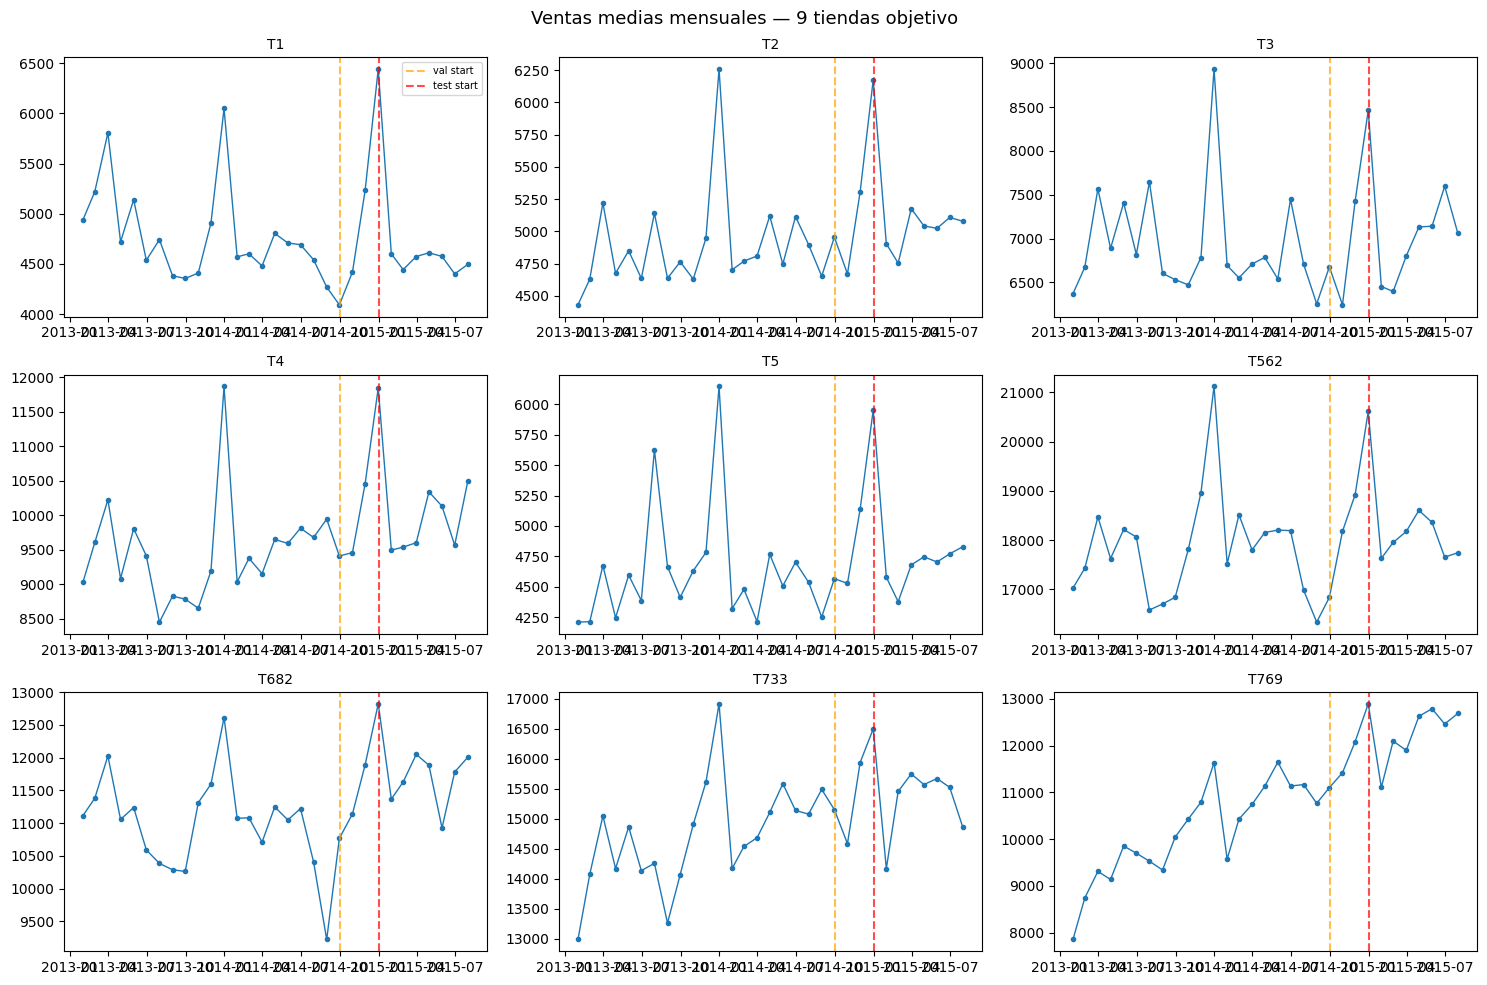

In [15]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()
for i, sid in enumerate(ev.TARGET_STORES):
    ax = axes[i]
    g = df[df["Store"] == sid].groupby(pd.Grouper(key="Date", freq="ME"))["Sales"].mean()
    ax.plot(g.index, g.values, marker="o", ms=3, linewidth=1)
    ax.axvline(pd.Timestamp("2014-10-01"), color="orange", linestyle="--", alpha=0.7, label="val start")
    ax.axvline(pd.Timestamp("2015-01-01"), color="red",    linestyle="--", alpha=0.7, label="test start")
    ax.set_title(f"T{sid}", fontsize=10)
    ax.set_xlabel("")
    if i == 0: ax.legend(fontsize=7)
plt.suptitle("Ventas medias mensuales — 9 tiendas objetivo", fontsize=13)
plt.tight_layout()
plt.show()

### Apendice B — Arquitectura del modelo (model.summary)

In [16]:
import os, sys
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)
import src.preprocessing as prep
import src.preprocessing_dani as dani

# Numero de tiendas y SEQ_LEN fijos
N_STORES, SEQ_LEN = 1115, 30

# -- Variante base (Baseline / E1 / E2 / E3) --
m_base = keras.models.model_from_json("""{}""") if False else None  # dummy

def _build(n_seq, n_num, seq_len=SEQ_LEN, drop=0.2, rnn='lstm', lstm2=None):
    n_cat = len(prep.STATIC_CAT_COLS)
    inp_seq    = keras.Input((seq_len, n_seq),       name='seq')
    inp_static = keras.Input((n_cat + n_num,),       name='static')
    inp_dow    = keras.Input((1,), dtype='int32',    name='dow')
    inp_month  = keras.Input((1,), dtype='int32',    name='month')
    if rnn == 'gru':
        x = L.GRU(64, name='gru')(inp_seq)
    elif lstm2:
        x = L.LSTM(64, return_sequences=True, name='lstm1')(inp_seq)
        x = L.Dropout(drop)(x)
        x = L.LSTM(lstm2, name='lstm2')(x)
    else:
        x = L.LSTM(64, name='lstm')(inp_seq)
    x = L.Dropout(drop)(x)
    x = L.Dense(64, activation='relu')(x)
    cat_specs = [(0,N_STORES,16,'emb_Store'),(1,4,2,'emb_StoreType'),
                 (2,3,2,'emb_Assortment'),(3,4,2,'emb_PromoInterval')]
    emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                    L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
                for i,v,d,nm in cat_specs]
    s = L.Concatenate()(emb_outs + [
        L.Flatten()(L.Embedding(7,  4, name='emb_dow')(inp_dow)),
        L.Flatten()(L.Embedding(12, 4, name='emb_month')(inp_month)),
        L.Lambda(lambda t: t[:, n_cat:])(inp_static),
    ])
    s = L.Dense(64, activation='relu')(s)
    s = L.Dropout(drop)(s)
    merged = L.Concatenate()([x, s])
    merged = L.Dense(128, activation='relu')(merged)
    merged = L.Dropout(drop)(merged)
    out = L.Dense(1, activation='linear', name='output')(merged)
    return keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)

configs = [
    ('Baseline/E1/E2/E3  — LSTM(64), 11 seq, 4 num',        11, 4, 'lstm', None, 0.2),
    ('E4/E8 base         — LSTM(64), 14 seq (lags), 4 num',  14, 4, 'lstm', None, 0.2),
    ('E5                 — LSTM(64), 15 seq (lags+slope)',    15, 4, 'lstm', None, 0.2),
    ('E6                 — LSTM(64), SEQ_LEN=60, 14 seq',    14, 4, 'lstm', None, 0.2),
    ('E7                 — LSTM(64), 13 seq, 5 num (dss)',    13, 5, 'lstm', None, 0.2),
    ('E8 dropout=0.35    — LSTM(64), 14 seq, drop=0.35',     14, 4, 'lstm', None, 0.35),
    ('E9                 — GRU(64),  14 seq, 4 num',         14, 4, 'gru',  None, 0.2),
    ('E10                — LSTM(64)+LSTM(32), 14 seq',       14, 4, 'lstm', 32,   0.2),
    ('E11                — LSTM(64), 14 seq, Huber loss',    14, 4, 'lstm', None, 0.2),
    # Tanda 4
    ('E12                — LSTM(64), 13 seq, 5 num, Huber', 13, 5, 'lstm', None, 0.2),
    ('E13                — LSTM(64), 14 seq (+promo2), 5 num', 14, 5, 'lstm', None, 0.2),
    ('E14                — LSTM(64), 13 seq, Huber, 10 ep',   13, 5, 'lstm', None, 0.2),
    ('E15                — LSTM(64), 14 seq (+promo2), Huber', 14, 5, 'lstm', None, 0.2),
    ('E16                — LSTM(64), 13 seq, Huber(d=1.5)',   13, 5, 'lstm', None, 0.2),
]

for label, n_seq, n_num, rnn, lstm2, drop in configs:
    seq_len = 60 if 'SEQ_LEN=60' in label else SEQ_LEN
    m = _build(n_seq, n_num, seq_len=seq_len, drop=drop, rnn=rnn, lstm2=lstm2)
    m.compile('adam', 'mse')
    print(f'\n{'='*65}')
    print(f'  {label}')
    print(f'{'='*65}')
    print(f'  Total params: {m.count_params():,}')
    del m


  Baseline/E1/E2/E3  — LSTM(64), 11 seq, 4 num
  Total params: 60,435

  E4/E8 base         — LSTM(64), 14 seq (lags), 4 num
  Total params: 61,203

  E5                 — LSTM(64), 15 seq (lags+slope)
  Total params: 61,459

  E6                 — LSTM(64), SEQ_LEN=60, 14 seq
  Total params: 61,203

  E7                 — LSTM(64), 13 seq, 5 num (dss)
  Total params: 61,011

  E8 dropout=0.35    — LSTM(64), 14 seq, drop=0.35
  Total params: 61,203

  E9                 — GRU(64),  14 seq, 4 num
  Total params: 56,339

  E10                — LSTM(64)+LSTM(32), 14 seq
  Total params: 71,571

  E11                — LSTM(64), 14 seq, Huber loss
  Total params: 61,203

  E12                — LSTM(64), 13 seq, 5 num, Huber
  Total params: 61,011

  E13                — LSTM(64), 14 seq (+promo2), 5 num
  Total params: 61,267

  E14                — LSTM(64), 13 seq, Huber, 10 ep
  Total params: 61,011

  E15                — LSTM(64), 14 seq (+promo2), Huber
  Total params: 61,267

  E16  

### Apendice C — Curvas de entrenamiento (todos los modelos)

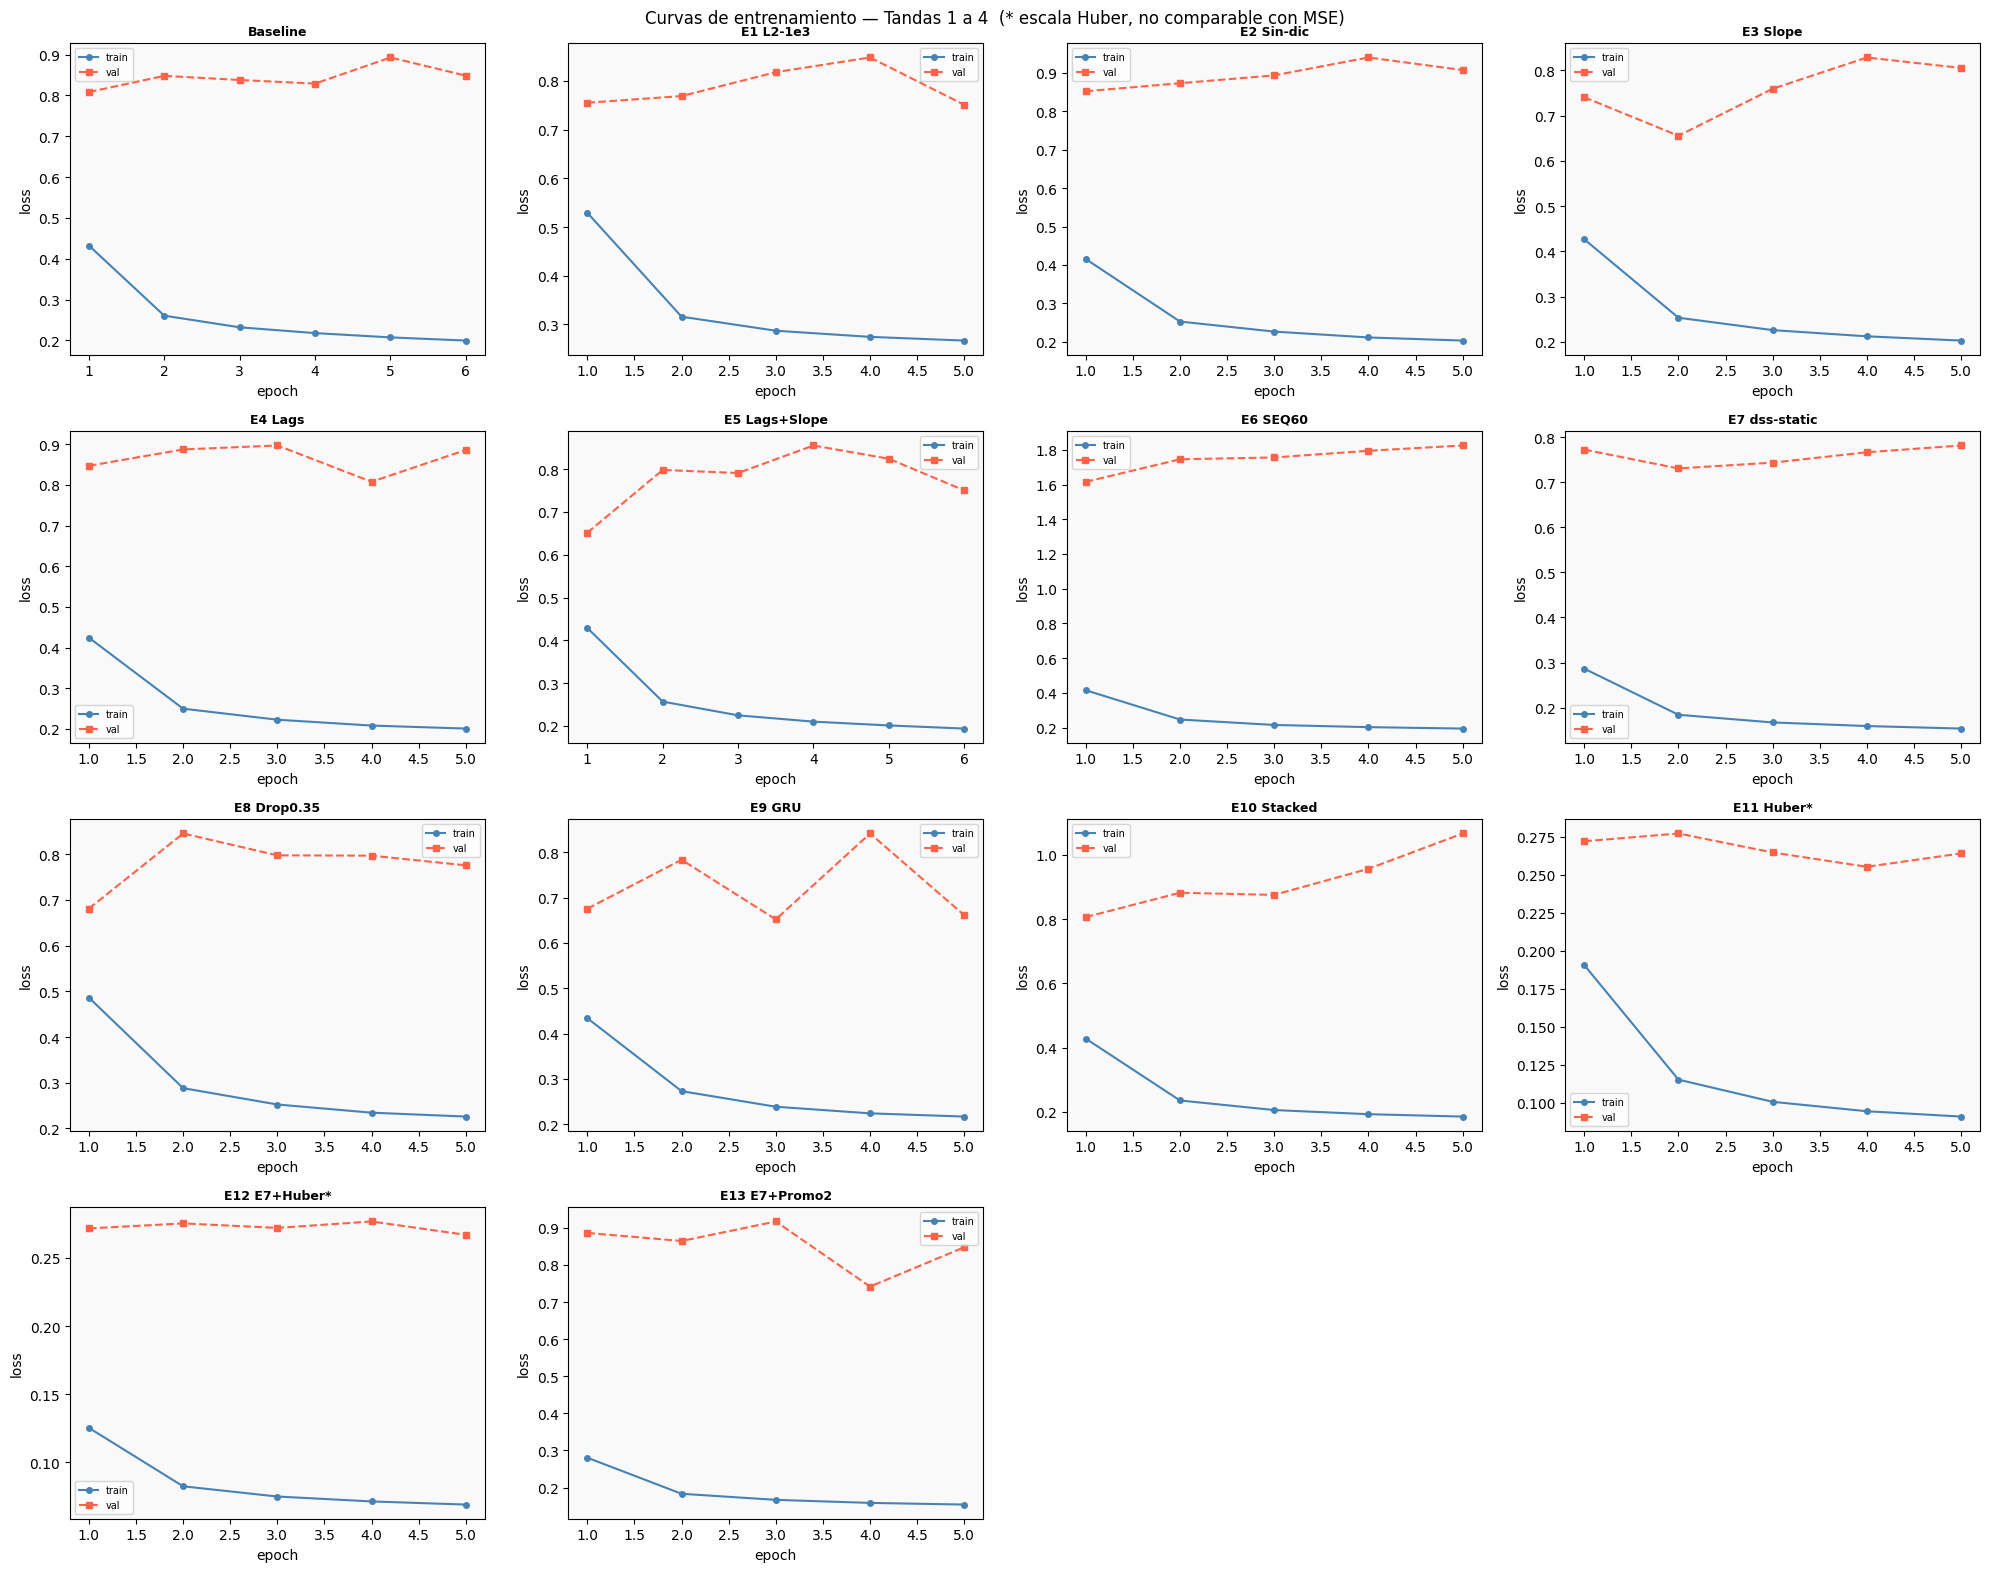

In [17]:
# Curvas de entrenamiento — valores extraidos de los outputs del notebook.
# Celda autocontenida: no depende de variables de sesion.
import matplotlib.pyplot as plt

T1 = {  # Tanda 1 + baseline
    'Baseline': {'loss':[0.4323,0.2604,0.2319,0.2177,0.2072,0.1994],
                 'val': [0.8083,0.8480,0.8379,0.8290,0.8930,0.8485]},
    'E1 L2-1e3':{'loss':[0.5292,0.3160,0.2872,0.2746,0.2670],
                 'val': [0.7550,0.7686,0.8177,0.8478,0.7507]},
    'E2 Sin-dic':{'loss':[0.4155,0.2526,0.2265,0.2112,0.2031],
                  'val': [0.8525,0.8734,0.8938,0.9404,0.9076]},
    'E3 Slope': {'loss':[0.4268,0.2533,0.2259,0.2122,0.2028],
                 'val': [0.7407,0.6555,0.7594,0.8285,0.8053]},
    'E4 Lags':  {'loss':[0.4243,0.2496,0.2225,0.2081,0.2007],
                 'val': [0.8469,0.8872,0.8969,0.8077,0.8859]},
}
T2 = {  # Tanda 2
    'E5 Lags+Slope':{'loss':[0.4290,0.2569,0.2248,0.2101,0.2012,0.1939],
                     'val': [0.6516,0.7982,0.7911,0.8554,0.8244,0.7504]},
    'E6 SEQ60':     {'loss':[0.4156,0.2471,0.2158,0.2032,0.1950],
                     'val': [1.6154,1.7453,1.7558,1.7943,1.8247]},
}
T3 = {  # Tanda 3
    'E7 dss-static':{'loss':[0.2865,0.1841,0.1671,0.1591,0.1535],
                     'val': [0.7725,0.7307,0.7436,0.7666,0.7816]},
    'E8 Drop0.35':  {'loss':[0.4864,0.2883,0.2525,0.2346,0.2261],
                     'val': [0.6812,0.8455,0.7977,0.7970,0.7758]},
    'E9 GRU':       {'loss':[0.4341,0.2731,0.2387,0.2241,0.2170],
                     'val': [0.6756,0.7835,0.6520,0.8415,0.6611]},
    'E10 Stacked':  {'loss':[0.4281,0.2355,0.2057,0.1928,0.1854],
                     'val': [0.8066,0.8824,0.8757,0.9569,1.0669]},
    'E11 Huber*':   {'loss':[0.1907,0.1153,0.1007,0.0945,0.0910],
                     'val': [0.2721,0.2772,0.2647,0.2553,0.2641]},
}

T4 = {  # Tanda 4
    'E12 E7+Huber*': {'loss': [0.1253, 0.0824, 0.0749, 0.0713, 0.0690],
                      'val':  [0.2716, 0.2753, 0.2720, 0.2767, 0.2669]},
    'E13 E7+Promo2': {'loss': [0.2804, 0.1832, 0.1668, 0.1586, 0.1541],
                      'val':  [0.8863, 0.8644, 0.9170, 0.7416, 0.8476]},
    # 'E14 E12+10ep*': {'loss': [...], 'val': [...]},
    # 'E15 E12+Promo2*': {'loss': [...], 'val': [...]},
    # 'E16 Huber d1.5*': {'loss': [...], 'val': [...]},
}

all_h = {**T1, **T2, **T3}
ncols = 4
n_plots = len(T1) + len(T2) + len(T3) + len(T4)
nrows = (n_plots + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows))
axes = axes.flatten()
colors = {'Tanda 1':'tab:blue','Tanda 2':'tab:orange','Tanda 3':'tab:green','Tanda 4':'tab:purple'}
groups = [('Tanda 1', T1), ('Tanda 2', T2), ('Tanda 3', T3)] + ([('Tanda 4', T4)] if T4 else [])

i = 0
for tanda_name, group in groups:
    for name, h in group.items():
        ax = axes[i]
        eps = range(1, len(h['loss'])+1)
        ax.plot(eps, h['loss'], 'o-', label='train', ms=4, color='steelblue')
        ax.plot(eps, h['val'],  's--',label='val',   ms=4, color='tomato')
        ax.set_title(f'{name}', fontsize=9, fontweight='bold')
        ax.set_facecolor('#f9f9f9')
        ax.legend(fontsize=7)
        ax.set_xlabel('epoch'); ax.set_ylabel('loss')
        i += 1

for j in range(i, len(axes)): axes[j].set_visible(False)
plt.suptitle('Curvas de entrenamiento — Tandas 1 a 4  (* escala Huber, no comparable con MSE)', fontsize=12)
plt.tight_layout()
plt.show()

### Apendice D — PCA de embeddings de tienda

In [18]:
# Apendice D — PCA de embeddings de tienda (mejor modelo: E12 — E7+Huber)
# Celda autocontenida: reconstruye arquitectura y carga pesos desde disco.
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers as L
from sklearn.decomposition import PCA

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if PROJECT_ROOT not in sys.path: sys.path.insert(0, PROJECT_ROOT)
import src.preprocessing as prep
import src.evaluate as ev

DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
OUTPUTS_DIR = os.path.join(PROJECT_ROOT, 'outputs')
SEQ_LEN, N_STORES = 30, 1115

# Cargar store_types para colorear
_, store_raw = prep.load_raw_data(DATA_DIR)
store_types = store_raw.set_index('Store')['StoreType'].to_dict()

# Reconstruir arquitectura E7 (13 seq, 5 num) y cargar pesos
n_cat = len(prep.STATIC_CAT_COLS)
inp_seq    = keras.Input((SEQ_LEN, 13),      name='seq')
inp_static = keras.Input((n_cat + 5,),       name='static')
inp_dow    = keras.Input((1,), dtype='int32', name='dow')
inp_month  = keras.Input((1,), dtype='int32', name='month')
x = L.LSTM(64, name='lstm')(inp_seq)
x = L.Dropout(0.2)(x)
x = L.Dense(64, activation='relu')(x)
cat_specs = [(0,N_STORES,16,'emb_Store'),(1,4,2,'emb_StoreType'),
             (2,3,2,'emb_Assortment'),(3,4,2,'emb_PromoInterval')]
emb_outs = [L.Flatten()(L.Embedding(v,d,name=nm)(
                L.Lambda(lambda t,i=i: tf.cast(t[:,i:i+1],tf.int32))(inp_static)))
            for i,v,d,nm in cat_specs]
s = L.Concatenate()(emb_outs + [
    L.Flatten()(L.Embedding(7,  4, name='emb_dow')(inp_dow)),
    L.Flatten()(L.Embedding(12, 4, name='emb_month')(inp_month)),
    L.Lambda(lambda t: t[:, n_cat:])(inp_static),
])
s = L.Dense(64, activation='relu')(s)
s = L.Dropout(0.2)(s)
merged = L.Concatenate()([x, s])
merged = L.Dense(128, activation='relu')(merged)
merged = L.Dropout(0.2)(merged)
out = L.Dense(1, activation='linear', name='output')(merged)
best_model = keras.Model(inputs=[inp_seq, inp_static, inp_dow, inp_month], outputs=out)
best_model.compile('adam', 'mse')
best_model.load_weights(os.path.join(OUTPUTS_DIR, 'exp12_e7_huber.weights.h5'))
print('Pesos E12 (mejor modelo: E7+Huber) cargados desde disco.')

# PCA 2D sobre embeddings de tienda
store_weights = best_model.get_layer('emb_Store').get_weights()[0]
coords = PCA(n_components=2).fit_transform(store_weights)
exp_var = PCA(n_components=2).fit(store_weights).explained_variance_ratio_

colors = {'a':'tab:blue','b':'tab:orange','c':'tab:green','d':'tab:red'}
plt.figure(figsize=(9, 7))
for sid in range(store_weights.shape[0]):
    st = store_types.get(sid + 1, 'a')
    plt.scatter(coords[sid, 0], coords[sid, 1], c=colors.get(st,'gray'), alpha=0.4, s=18)
for sid in ev.TARGET_STORES:
    idx = sid - 1
    st = store_types.get(sid, 'a')
    plt.scatter(coords[idx, 0], coords[idx, 1], c=colors.get(st,'gray'),
                edgecolors='black', s=90, zorder=5, label=f'T{sid}')
from matplotlib.lines import Line2D
legend_types = [Line2D([0],[0],marker='o',color='w',markerfacecolor=c,markersize=8,label=f'Tipo {k}')
                for k,c in colors.items()]
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles=legend_types + handles, ncol=2, fontsize=7)
plt.title(f'PCA 2D embeddings de tienda — modelo E7 (16d→2d)')
plt.xlabel(f'PC1 ({exp_var[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]*100:.1f}%)')
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'c:\Users\Usuario\Downloads\TAREA_ENTRADAS_HETEROGENEAS\outputs\exp12_e7_huber.weights.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)